In [1]:
#if fresh enviornment, in terminal
'''
chmod +x dependencies.sh
./dependencies.sh
'''
import sys
print(sys.executable)

/home/ec2-user/anaconda3/envs/python3/bin/python


In [2]:
# Load dependencies
packages = [
    "transformers",
    "datasets",
    "iterative-stratification",
    "seaborn",
    "matplotlib",
    "nltk",
    "torch",
    "ftfy",
    "Levenshtein",
]

!pip install -q {" ".join(packages)}

  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [iterative-stratification]learn]
  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metad

In [3]:
# Standard library
import copy
import glob
import itertools
import json
import math
import os
import random
import re
import warnings
from collections import Counter

# Third-party: Data processing
import ftfy
import Levenshtein
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import wordnet
from nltk.tokenize.punkt import PunktSentenceTokenizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# Multilabel stratified splitting
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit as MSSS

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Transformers
from transformers import (
    AutoModel,
    AutoModelForSeq2SeqLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

# Suppress warnings
warnings.filterwarnings("ignore")

# Download required NLTK data
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("punkt_tab")
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("punkt", quiet=True)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
#load data into df
#load the json training_set_task1.txt
with open("training_set_task1.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

#load into pandas DataFrame
df = pd.DataFrame(data)

# Count using pandas (if 'labels' is a column containing lists)
empty_label_count = df["labels"].apply(lambda x: len(x) == 0).sum()

print(f"Number of entries with empty labels: {empty_label_count}")

#save entries with empty labels into a seperate DF for checking
empty_labels_df = df[df["labels"].map(len) == 0].copy()

# Keep only valid non-empty entries in your primary DataFrame
df = df[df["labels"].map(len) > 0].copy()

# Verify the row counts
print(f"Valid entries saved to df: {len(df)}")
print(f"Empty label entries saved to empty_labels_df: {len(empty_labels_df)}")


Number of entries with empty labels: 143
Valid entries saved to df: 545
Empty label entries saved to empty_labels_df: 143


In [5]:
'''
### google.colab. colab version
from google.colab import drive

#mount Drive
drive.mount("/content/drive")

#define path 'ass2' folder
folder_path = "/content/drive/MyDrive/assignment2"
file_path = os.path.join(folder_path, "training_set_task1.txt")

#load data into JSON
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

#load into pandas DataFrame
df = pd.DataFrame(data)

#count empty labels
empty_label_count = df["labels"].apply(lambda x: len(x) == 0).sum()
print(f"Number of entries with empty labels: {empty_label_count}")

#save entries with empty labels into empty_labels_df
empty_labels_df = df[df["labels"].map(len) == 0].copy()

#Keep only valid non-empty entries in df
df = df[df["labels"].map(len) > 0].copy()
'''

ModuleNotFoundError: No module named 'google.colab'

In [6]:
print(f"Valid training entries: {len(df)}")
print(f"Empty-label entries: {len(empty_labels_df)}")

Valid training entries: 545
Empty-label entries: 143


In [7]:
labels = df["labels"].apply(lambda x: x[0])

print(df[["text", "labels"]].head())

print(labels.value_counts().sort_index())

print(labels.unique())

                                                text  \
0    THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n   
2  SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...   
3  PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...   
5  Our elders were called to war to save lives.\n...   
6  Adolf Hitler\n• Believed state power would fix...   

                                              labels  
0             [Black-and-white Fallacy/Dictatorship]  
2  [Loaded Language, Name calling/Labeling, Sloga...  
3  [Causal Oversimplification, Loaded Language, N...  
5  [Appeal to fear/prejudice, Causal Oversimplifi...  
6  [Loaded Language, Name calling/Labeling, Reduc...  
labels
Appeal to authority                                     13
Appeal to fear/prejudice                                42
Bandwagon                                                2
Black-and-white Fallacy/Dictatorship                    12
Causal Oversimplification                               21
Doubt                          

In [ ]:
'''
### google.colab. save to file
from google.colab import files
folder_path = "/content/drive/MyDrive/assignment2"
df.to_csv(f"{folder_path}/training_set_task1.csv", index=False)
'''

In [8]:
# Class weights for imbalanced data

#get all the labels
all_labels = list(itertools.chain.from_iterable(df["labels"]))

#extract a list of unique labels, sorted
label_names = sorted(list(set(all_labels)))
#get number of classes
NUM_CLASSES = len(label_names)

#give class count
class_counts = Counter(all_labels)

#compute inverse frequency weights
total_occurrences = len(all_labels)
#iterate through 'label_names'
class_weights = torch.tensor(
    [total_occurrences / max(1, class_counts.get(name, 0)) for name in label_names],
    dtype=torch.float32
).to(device)

#normalize weights so they average to 1.0
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

#formatted results
print('Class weights (inverse frequency):')
for i, name in enumerate(label_names):
    print(f'  {name}: {class_weights[i].item():.2f}')


Class weights (inverse frequency):
  Appeal to authority: 0.63
  Appeal to fear/prejudice: 0.19
  Bandwagon: 4.09
  Black-and-white Fallacy/Dictatorship: 0.45
  Causal Oversimplification: 0.30
  Doubt: 0.17
  Exaggeration/Minimisation: 0.16
  Flag-waving: 0.30
  Glittering generalities (Virtue): 0.26
  Loaded Language: 0.02
  Misrepresentation of Someone's Position (Straw Man): 0.41
  Name calling/Labeling: 0.04
  Obfuscation, Intentional vagueness, Confusion: 2.04
  Presenting Irrelevant Data (Red Herring): 8.17
  Reductio ad hitlerum: 0.91
  Repetition: 1.02
  Slogans: 0.19
  Smears: 0.04
  Thought-terminating cliché: 0.41
  Whataboutism: 0.20


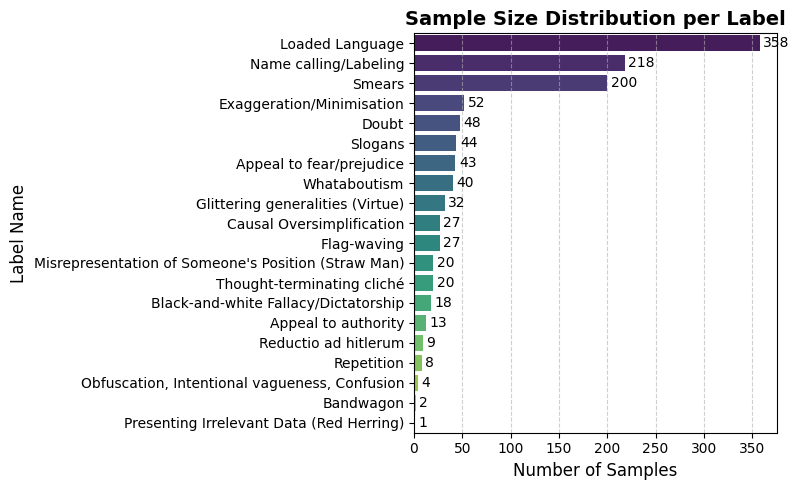

In [9]:
# Extract labels and counts sorted by frequency
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_counts)

# Create plot
#plt.figure(figsize=(10, len(labels) * 0.4 + 2))
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counts), y=list(labels), hue=list(labels), palette="viridis", legend=False)

plt.xlabel("Number of Samples", fontsize=12)
plt.ylabel("Label Name", fontsize=12)
plt.title("Sample Size Distribution per Label", fontsize=14, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Annotate bars with exact counts
for index, count in enumerate(counts):
    plt.text(count + (max(counts) * 0.01), index, f"{count:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

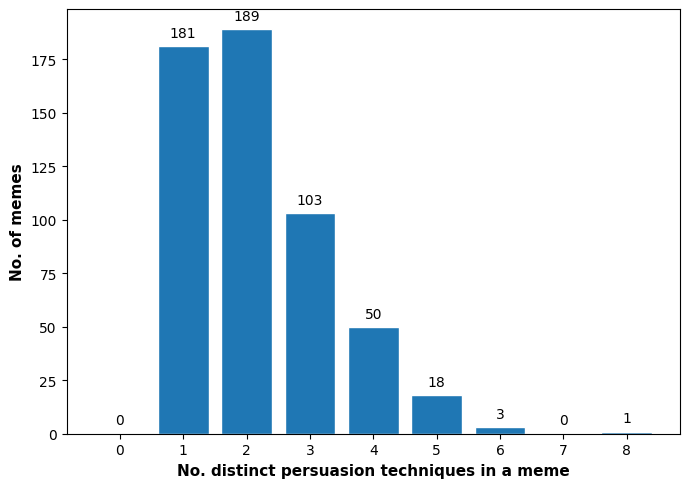

In [10]:
### for Task 1 ###
#get distinct techniques
distinct_counts = df['labels'].apply(lambda x: len(set(x)) if isinstance(x, (list, set, tuple)) else (1 if pd.notna(x) else 0))
#freq distr
distribution = distinct_counts.value_counts()

max_techniques = distribution.index.max() if len(distribution) > 0 else 0
distribution = distribution.reindex(range(0, max_techniques + 1), fill_value=0)

#chart
x_values = distribution.index
y_values = distribution.values
plt.figure(figsize=(7, 5))
bars = plt.bar(x_values, y_values, color='#1f77b4', edgecolor='white')
#format labels
plt.xlabel("No. distinct persuasion techniques in a meme", fontsize=11, fontweight="bold")
plt.ylabel("No. of memes", fontsize=11, fontweight="bold")
plt.xticks(x_values)
# show counts for each bar
max_y = max(y_values) if len(y_values) > 0 else 1
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max_y * 0.015),
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()



In [11]:
#pick and print one sample 'text' for each unique label
print("Sample text per label:")
for label in label_names:
    # Filter for rows where 'label' is in the row's list of labels
    matching_rows = df[df["labels"].apply(lambda labels: label in labels)]

    if not matching_rows.empty:
        # Get the 'text' of the first matching sample
        sample_text = matching_rows.iloc[0]["text"]
        print(f"\n--- Label: {label} ---")
        print(sample_text)
    else:
        print(f"\n--- Label: {label} ---")
        print("[No matching sample found]")

Sample text per label:

--- Label: Appeal to authority ---
"If a law is unjust, a man is not only right to disobey it, he is obligated to do so."
 -Thomas Jefferson


--- Label: Appeal to fear/prejudice ---
Our elders were called to war to save lives.
We are being called to sit on the couch to save theirs.
We can do this.


--- Label: Bandwagon ---
If you support this man, I won't judge you for your choice of political parties. 
I will judge you for your lack of morals, ethics and humanity.
So will others.
So will history.


--- Label: Black-and-white Fallacy/Dictatorship ---
THERE ARE ONLY TWO GENDERS

FEMALE 

MALE


--- Label: Causal Oversimplification ---
PATHETIC

The Cowardly Asshole
Weak Failure!!!

Impeach it again!!!

# 45 the coward s afraid of strong women!!

POLITICUSUSA.COM
Childish Trump Won't Meet With Pelosi On Coronavirus
Because He Doesn't Like Her


--- Label: Doubt ---
Reminder: This building in Oklahoma City was blown up and destroyed just 4 days before Hillary Cli

* Looking at the samples from each category, the task requires contextual understanding, where the order of the words matters, rather than simple keyword matching. Therefore, a Bag-of-Words approach may not be suitable, as it does not capture the relationships between words. A self-attention approach can better capture these contextual relationships and dependencies within the text. A transformer approach would be ideal.

* Given that there are only 545 training samples, using a model pre-trained on a large text corpus would be beneficial. A pre-trained model should be able to  capture aspects of grammar and sentiment, reducing the amount of data that is required to learn these patterns compared with training a model from scratch.

* Furthermore, to maximise performance given the small dataset, 5-fold cross-validation can be used. MultilabelStratifiedKFold divides the dataset into five folds while maintaining a similar distribution of the rare classes across each fold. Five separate model instances are then trained, with each model using four folds for training and the remaining fold for validation. The predictions from the five models can then be averaged to produce the final prediction.


* There is large label disparity.. The dataset is imbalanced, with labels such as "Loaded Language", "Name Calling/Labeling" and "Smears" accounting for a large proportion of the training samples with > than 25% of the samples, labels like Bandwagon, Irrelevant Data, and Confusion are present in less than 2% of the data. As a result, standard Binary Cross-Entropy (BCE) may not adequately account for underrepresented positive labels, potentially leading to poorer performance with the minority classes. Therefore, Weighted Binary Cross-Entropy (Weighted BCE) can be used to address this imbalance by assigning higher weights to positive instances of less frequent classes, with weights inversely proportional to their frequency. This helps the model put greater weight on learning under-represented labels.

* Because the class distribution is imbalanced, Macro F1 will be used as the primary evaluation metric, as it assigns equal importance to each class and therefore provides greater sensitivity to performance on minority classes. In contrast, Micro F1 aggregates true positives, false positives, and false negatives across all classes, meaning that its score is influenced more heavily by the majority classes. Therefore, Micro F1 will be used as a supplementary metric to Macro F1 to provide additional insight into overall performance across the observed class distribution.

* From the current bechmark from, Dimitrov et al. (2021):
   * For Task 1. Team MinD archieved a F1-Micro score of .593 and .290 so this model should at least archieve the same benchmark score.
   * For Task 2. Team Volta archieved for F1: .482, Precision: .501, Recall: .464.
   * MinD did not compete on Task 2, only on Task 1 and Task 3. Volta archieved the best combination of both Task 1 and Task 2 with F1-Micro: .570 and F1-Macro .266
   * For these experiments the benchmark for both Tasks will be:
      * Task 1: F1-Micro: .570 and F1-Macro .266
      * Task 2: F1: .482, Precision: .501, Recall: .464.

* Dimitrov et al. (2021) mentions that there are biases in the training data:
That there are sizable disparities in the frequency of different techniques accross the data set.
The data set was sourced to 26 specific facebook groups, that were heavily focused on the politcics, pandamic, vaccines and gender equality. The uses of this solution may not use the same techniques or types of memes, if we solely train the model only on the SemEval-2021 Task 6 training samples.

* As the dataset may not accurately represent the data that users are likely to generate in real-world scenarios, using a pre-trained model may improve generalisation by leveraging representations learned from a broader and more diverse dataset than the available training set.

* Augmentation was used by some teams in (Dimitrov et al., 2021):
  * Such as by Team LIIR which used paraphrased augmentations of the orginal meme with back tranlsation where the text is translated to another language and then back again.
  * Team LeCun (Da San Martino et al., 2020) merged the data set with the additional external news/text propaganda dataset, aswell as multi step back translation between English, Dutch, Russian and English - thr process from (Daval-Frerot & Weis, 2020). A Clear back translation process is mentioned by Team LIIR (Ghadery et al., 2021) where they paraphrased each original sentence by translating it into a target language and then translating it back to the original language, English to German and back again.

* Becuase the data set is small to increase the size, the PTC corpus ( which has more than 20,000 sentences) from SemEval-2020 task 11 (Da San Martino et al., 2020) can be included. It was used in MinD ensamble approach (Tian et al., 2021). A subset of the data was retrived from (https://zenodo.org/records/3952415). MinD uses a process (sentence-level annotations) where they extract the label sample from the article with the start and end positions.

* For Task 1 (Gupta et al., 2021) Volta uses transfer learning with small and large variants of models - BERT and RoBERTa.

* For Task 1 (Tian et al., 2021) MinD uses transfer learninig with pretrained model RoBERTa, that has the advantage of dynamic masking and Byte-Pair Encoding (BPE) (Sennrich et al., 2016), it archieves a F1-Micro score of 0.6478 on the dev data set. They however use an ensemble by averaging the predictions across RoBERTa, XLNet, DeBERTa, and ALBERT for Task 1.




In [12]:
print(df.head())

    id                                             labels  \
0  128             [Black-and-white Fallacy/Dictatorship]   
2   96  [Loaded Language, Name calling/Labeling, Sloga...   
3  154  [Causal Oversimplification, Loaded Language, N...   
5  169  [Appeal to fear/prejudice, Causal Oversimplifi...   
6  145  [Loaded Language, Name calling/Labeling, Reduc...   

                                                text  
0    THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n  
2  SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...  
3  PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...  
5  Our elders were called to war to save lives.\n...  
6  Adolf Hitler\n• Believed state power would fix...  


In [13]:
# Valid class headings
df_labels = [
    "Appeal to authority",
    "Appeal to fear/prejudice",
    "Black-and-white Fallacy/Dictatorship",
    "Causal Oversimplification",
    "Doubt",
    "Exaggeration/Minimisation",
    "Flag-waving",
    "Glittering generalities (Virtue)",
    "Loaded Language",
    "Misrepresentation of Someone's Position (Straw Man)",
    "Name calling/Labeling",
    "Obfuscation, Intentional vagueness, Confusion",
    "Presenting Irrelevant Data (Red Herring)",
    "Reductio ad hitlerum",
    "Repetition",
    "Slogans",
    "Smears",
    "Thought-terminating cliché",
    "Whataboutism",
    "Bandwagon",
    "Transfer",
    "Appeal to (Strong) Emotions"
]
label_lookup = {label: label for label in df_labels}

In [14]:
#show the class counts of DF (training_set_task1.txt)
label_counts = (
    df["labels"]
    .dropna()
    .explode()
    .map(lambda x: label_lookup.get(x, x))
    .dropna()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

print(label_counts)

labels
Appeal to authority                                     13
Appeal to fear/prejudice                                43
Black-and-white Fallacy/Dictatorship                    18
Causal Oversimplification                               27
Doubt                                                   48
Exaggeration/Minimisation                               52
Flag-waving                                             27
Glittering generalities (Virtue)                        32
Loaded Language                                        358
Misrepresentation of Someone's Position (Straw Man)     20
Name calling/Labeling                                  218
Obfuscation, Intentional vagueness, Confusion            4
Presenting Irrelevant Data (Red Herring)                 1
Reductio ad hitlerum                                     9
Repetition                                               8
Slogans                                                 44
Smears                                           

* Stratified splitting requires that there is at least 2 samples per class, the following classes only have a single sample:           1
   * Presenting Irrelevant Data (Red Herring)                 1    
* Data Augmentation can solve this and adding more samples, Adding the samples from the PTC data set for the to try and obtain a better balance        

In [ ]:
'''
#### google.colab.  File paths
articles_dir = '/content/drive/MyDrive/assignment2/PTC-data/train-articles'
labels_file = '/content/drive/MyDrive/assignment2/PTC-data/train-task2-TC.labels'
'''

In [15]:
#### File paths
articles_dir = 'PTC-data/train-articles'
labels_file = 'PTC-data/train-task2-TC.labels'

In [16]:
#extract the text span from the articles to check with the span looks like

# 1. Read labels file directly
labels_df = pd.read_csv(
    labels_file,
    sep='\t',
    header=None,
    names=['article_id', 'label', 'start', 'end']
)
labels_df['article_id'] = labels_df['article_id'].astype(str)

# 2. Gather full article text contents
articles_data = []
for file_path in glob.glob(os.path.join(articles_dir, 'article*.txt')):
    filename = os.path.basename(file_path)
    article_id = filename.replace('article', '').replace('.txt', '')

    with open(file_path, 'r', encoding='utf-8') as file:
        text_content = file.read()

    articles_data.append({
        'article_id': article_id,
        'text': text_content
    })

articles_df = pd.DataFrame(articles_data)

# 3. Merge raw label entries with article texts
ptc_df = pd.merge(labels_df, articles_df, on='article_id', how='left')

# 4. Extract snippet by slicing text using character offsets
ptc_df['extracted_text'] = ptc_df.apply(
    lambda row: row['text'][int(row['start']):int(row['end'])] if pd.notna(row['text']) else '',
    axis=1
)

# 5. Clean up columns order
ptc_df = ptc_df[['article_id', 'label', 'start', 'end', 'extracted_text']]

# Display result
display(ptc_df.head())

,article_id,label,start,end,extracted_text
0,111111111,Appeal_to_Authority,265,323,The next transmission could be more pronounced...
1,111111111,Appeal_to_Authority,1795,1935,when (the plague) comes again it starts from m...
2,111111111,Doubt,149,157,appeared
3,111111111,Repetition,1069,1091,"a very, very different"
4,111111111,Appeal_to_fear-prejudice,1334,1462,He also pointed to the presence of the pneumon...


We can see that the context is lost if only extracting the span text related to the label. MinD in (Da San Martino et al., 2020) mentions that there models performed particulary bad on certain labels such as "Repetition" (page 1086. Table. 7), Red Herring. They also used Sentence Boundary Segmentation where the split of the text is at the sentence level encapsulating the label position span and the start and end of that sentence.


In [17]:


# Ensure the punkt tokenizer models are downloaded
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
tokenizer = PunktSentenceTokenizer()


# 1. Read labels file directly
labels_df = pd.read_csv(
    labels_file,
    sep='\t',
    header=None,
    names=['article_id', 'label', 'start', 'end']
)
labels_df['article_id'] = labels_df['article_id'].astype(str)

# 2. Gather full article texts AND perform sentence segmentation
sentence_data = []
for file_path in glob.glob(os.path.join(articles_dir, 'article*.txt')):
    filename = os.path.basename(file_path)
    article_id = filename.replace('article', '').replace('.txt', '')

    with open(file_path, 'r', encoding='utf-8') as file:
        text_content = file.read()

    # Use span_tokenize to get the start and end character indices of each sentence
    for sent_start, sent_end in tokenizer.span_tokenize(text_content):
        sentence_data.append({
            'article_id': article_id,
            'sent_start': sent_start,
            'sent_end': sent_end,
            'sentence_text': text_content[sent_start:sent_end]
        })

sentences_df = pd.DataFrame(sentence_data)

# 3. Create a dictionary of labels grouped by article_id for fast lookup
labels_dict = (
    labels_df.groupby('article_id')
    .apply(lambda x: x[['label', 'start', 'end']].to_dict('records'))
    .to_dict()
)

# 4. Map labels to sentences based on character offset overlap
def map_labels_to_sentence(row):
    art_id = row['article_id']
    sent_start = row['sent_start']
    sent_end = row['sent_end']

    if art_id not in labels_dict:
        return []

    matched_labels = []
    for lbl in labels_dict[art_id]:
        lbl_start = int(lbl['start'])
        lbl_end = int(lbl['end'])

        # Check for overlap: if max of starts < min of ends, the text spans intersect
        if max(sent_start, lbl_start) < min(sent_end, lbl_end):
            matched_labels.append(lbl['label'])

    # Return unique labels (in case multiple spans in one sentence have the same label)
    return list(set(matched_labels))

sentences_df['labels'] = sentences_df.apply(map_labels_to_sentence, axis=1)

# 5. Clean up columns and filter out sentences with no text (e.g., standalone newlines)
sentences_df = sentences_df[['article_id', 'sent_start', 'sent_end', 'sentence_text', 'labels']]
sentences_df = sentences_df[sentences_df['sentence_text'].str.strip().astype(bool)]

# Display result
display(sentences_df.head(10))

/tmp/ipykernel_35753/1754049356.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[['label', 'start', 'end']].to_dict('records'))


,article_id,sent_start,sent_end,sentence_text,labels
0,701225819,0,207,South Florida Muslim Leader Sofian Zakkout’s D...,"[Name_Calling,Labeling, Appeal_to_fear-prejudice]"
1,701225819,208,382,"However, one individual who represents the Mus...",[Loaded_Language]
2,701225819,383,525,"Last month, once again, Zakkout chose to showc...",[]
3,701225819,526,595,The postings can be rivaled only by Zakkout’s ...,[]
4,701225819,596,698,Sofian Abdelaziz Zakkout is the President of t...,[]
5,701225819,699,785,He has ties to two dozen mosques stretching fr...,[]
6,701225819,786,868,"On September 21, 2017, Zakkout took to Faceboo...",[]
7,701225819,869,1019,Three of the videos were put out by Duke’s off...,"[Name_Calling,Labeling]"
8,701225819,1020,1178,The fourth video was a news report featuring a...,[]
9,701225819,1179,1300,"At this same rally, a white nationalist plowed...",[Appeal_to_fear-prejudice]


In [19]:
#filter out empty label entries from sentence_df
positive_sentences_df = sentences_df[sentences_df['labels'].map(len) > 0].reset_index(drop=True)
display(positive_sentences_df.head())

,article_id,sent_start,sent_end,sentence_text,labels
0,701225819,0,207,South Florida Muslim Leader Sofian Zakkout’s D...,"[Name_Calling,Labeling, Appeal_to_fear-prejudice]"
1,701225819,208,382,"However, one individual who represents the Mus...",[Loaded_Language]
2,701225819,869,1019,Three of the videos were put out by Duke’s off...,"[Name_Calling,Labeling]"
3,701225819,1179,1300,"At this same rally, a white nationalist plowed...",[Appeal_to_fear-prejudice]
4,701225819,1396,1496,"In February 2016, Zakkout publicized on his Fa...",[Appeal_to_fear-prejudice]


some of the data has bad unnormal characters such as:

    "‚Äî bishops have a very grave responsibility."
These will be removed as they could cause issues in the model training


In [20]:
positive_sentences_df['sentence_text'] = positive_sentences_df['sentence_text'].apply(ftfy.fix_text)
display(positive_sentences_df.head())

,article_id,sent_start,sent_end,sentence_text,labels
0,701225819,0,207,South Florida Muslim Leader Sofian Zakkout's D...,"[Name_Calling,Labeling, Appeal_to_fear-prejudice]"
1,701225819,208,382,"However, one individual who represents the Mus...",[Loaded_Language]
2,701225819,869,1019,Three of the videos were put out by Duke's off...,"[Name_Calling,Labeling]"
3,701225819,1179,1300,"At this same rally, a white nationalist plowed...",[Appeal_to_fear-prejudice]
4,701225819,1396,1496,"In February 2016, Zakkout publicized on his Fa...",[Appeal_to_fear-prejudice]


In [21]:
print(positive_sentences_df.columns.tolist())

['article_id', 'sent_start', 'sent_end', 'sentence_text', 'labels']


There are still issues that can be seen in the samples, example:
Article: 699478811,
label:['Appeal_to_fear-prejudice'],
text:  "Thus, it is threatening U.S."
From the main text: "Thus, it is threatening U.S. forces and bases in the region."

We can see that the sentence extraction logic has ended the sentence prematurally due to the full stop after U.S, "." and not included forces. This can be tricky as it is gramatically should be "threatening U.S forces..." hence it is not perfect but maybe there are enough good samples to over come the misleading cases.

In [21]:
'''
#### google.colab. save to file
from google.colab import files
folder_path = "/content/drive/MyDrive/assignment2"
positive_sentences_df.to_csv(f"{folder_path}/positive_sentences_df.csv", index=False)
'''

ModuleNotFoundError: No module named 'google.colab'

In [22]:
#positive_sentences_df = positive_sentences_df.to_frame()

In [23]:
#align the ptc_df so that it has the same names as DF (training_set_task1.txt) so that a comparison can be done
#mapping from current PTC labels -> desired label names
label_mapping = {
    "Appeal_to_Authority": "Appeal to authority",
    "Appeal_to_fear-prejudice": "Appeal to fear/prejudice",
    "Black-and-White_Fallacy": "Black-and-white Fallacy/Dictatorship",
    "Causal_Oversimplification": "Causal Oversimplification",
    "Exaggeration": "Exaggeration/Minimisation",
    "Flag-Waving": "Flag-waving",
    "Loaded_Language": "Loaded Language",
    "Straw_Men": "Misrepresentation of Someone's Position (Straw Man)",
    "Labeling": "Name calling/Labeling",
    "Name_Calling": "Name calling/Labeling",
    "Red_Herring": "Presenting Irrelevant Data (Red Herring)",
    "Reductio_ad_hitlerum": "Reductio ad hitlerum",
    "Thought-terminating_Cliches": "Thought-terminating cliché",
    "Minimisation": "Exaggeration/Minimisation"
}

#update labels in ptc_df
def update_labels(labels):
    updated = []

    for label in labels:
        #some entries contain multiple labels separated by commas
        for individual_label in str(label).split(","):
            individual_label = individual_label.strip()

            #replace with desired name if it exists in the mapping
            updated.append(
                label_mapping.get(individual_label, individual_label)
            )

    return updated


positive_sentences_df["labels"] = positive_sentences_df["labels"].apply(update_labels)

In [24]:
#show the class counts of DF (training_set_task1.txt)
ptc_label_counts = (
    positive_sentences_df["labels"]
    .dropna()
    .explode()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print(ptc_label_counts)

labels
Loaded Language                                        1885
Name calling/Labeling                                  1880
Exaggeration/Minimisation                               928
Doubt                                                   630
Repetition                                              581
Appeal to fear/prejudice                                347
Causal Oversimplification                               260
Flag-waving                                             242
Appeal to authority                                     178
Black-and-white Fallacy/Dictatorship                    135
Slogans                                                 125
Whataboutism                                            121
Misrepresentation of Someone's Position (Straw Man)     121
Presenting Irrelevant Data (Red Herring)                121
Thought-terminating cliché                               81
Reductio ad hitlerum                                     80
Bandwagon                        

In [25]:
# -----------------------------
# DF class counts
# -----------------------------
df_counts = (
    df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

# -----------------------------
# PTC class counts
# -----------------------------
ptc_counts = (
    positive_sentences_df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)

# -----------------------------
# Combine into one table
# -----------------------------
class_counts = pd.DataFrame({
    "Label": df_labels,
    "DF Count": df_counts.values,
    "PTC Count": ptc_counts.values
})

# Add total count
class_counts["Total"] = class_counts["DF Count"] + class_counts["PTC Count"]

display(class_counts)

,Label,DF Count,PTC Count,Total
0,Appeal to authority,13,178,191
1,Appeal to fear/prejudice,43,347,390
2,Black-and-white Fallacy/Dictatorship,18,135,153
3,Causal Oversimplification,27,260,287
4,Doubt,48,630,678
5,Exaggeration/Minimisation,52,928,980
6,Flag-waving,27,242,269
7,Glittering generalities (Virtue),32,0,32
8,Loaded Language,358,1885,2243
9,Misrepresentation of Someone's Position (Straw...,20,121,141


* The thing to consider is that the lists are made up of single and multi labeled samples, so for instance in PTC Count-> Exaggeration had 171, and Minimisation had 171, as a result of being joined the total is 342.
* The Total column shows the new qty for the class if we join the new data to the existing samples. Although it is still imbalanced it provides more to work with.
* Also there are still empty classes "Transfer" and "Appeal to (Strong) Emotions"


In [26]:
#print off a few from df to see that format difference
df = df.sort_values(by='id')
display(df.head())

,id,labels,text
32,1,"[Causal Oversimplification, Glittering general...",8 YEARS UNDER OBAMA\n4 MILLION JOBS LOST\nUNEM...
145,100_batch_2,"[Smears, Thought-terminating cliché]",If Amy Coney Barrett doesn't have the common s...
89,102,"[Doubt, Exaggeration/Minimisation, Name callin...",I HAVE A CHANCE TO BE THE FIRST GAY UNITED STA...
179,103_batch_2,[Smears],"BURGER KING\n\n""Forget about the Presidency fo..."
10,104,"[Appeal to fear/prejudice, Loaded Language, Sl...",SCARE TATICS BY THE LEFT.\n\nClose businesses\...


In [27]:
#print off a few from df to see that format difference
ptc_df_show = positive_sentences_df.sort_values(by='article_id')
display(ptc_df_show.head())

,article_id,sent_start,sent_end,sentence_text,labels
946,111111111,1952,2099,"""That means that Madagascar could be affected ...",[Appeal to fear/prejudice]
945,111111111,1718,1950,This along with poor sanitation and vector con...,"[Appeal to authority, Appeal to fear/prejudice]"
944,111111111,1465,1617,He praised the rapid response from WHO and Mad...,[Appeal to fear/prejudice]
943,111111111,1334,1463,He also pointed to the presence of the pneumon...,[Appeal to fear/prejudice]
942,111111111,1007,1107,"But Tedros voiced alarm that ""plague in Madaga...",[Repetition]


In [28]:
#combine text sentence instances so that sentences with multiple labels are grouped together,
#with all associated labels stored as a list. This is so that there isn't duplicated

# 1. Create normalized text key on positive_sentences_df
positive_sentences_df["text_key"] = (
    positive_sentences_df["sentence_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 2. Group by text_key to combine duplicate sentences and flatten their labels
positive_sentences_grouped = (
    positive_sentences_df.groupby("text_key", as_index=False)
    .agg({
        "article_id": "first",
        "sentence_text": "first",
        "labels": lambda label_series: list(dict.fromkeys(
            lbl
            for item in label_series
            for lbl in (item if isinstance(item, list) else [item])
            if lbl
        ))
    })
)


In [29]:
display(positive_sentences_df.head())

,article_id,sent_start,sent_end,sentence_text,labels,text_key
0,701225819,0,207,South Florida Muslim Leader Sofian Zakkout's D...,"[Name calling/Labeling, Name calling/Labeling,...",South Florida Muslim Leader Sofian Zakkout's D...
1,701225819,208,382,"However, one individual who represents the Mus...",[Loaded Language],"However, one individual who represents the Mus..."
2,701225819,869,1019,Three of the videos were put out by Duke's off...,"[Name calling/Labeling, Name calling/Labeling]",Three of the videos were put out by Duke's off...
3,701225819,1179,1300,"At this same rally, a white nationalist plowed...",[Appeal to fear/prejudice],"At this same rally, a white nationalist plowed..."
4,701225819,1396,1496,"In February 2016, Zakkout publicized on his Fa...",[Appeal to fear/prejudice],"In February 2016, Zakkout publicized on his Fa..."


In [30]:
# -----------------------------
# Create normalised text keys
# -----------------------------
'''
positive_sentences_df["text_key"] = (
    positive_sentences_df["sentence_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)'''

df["text_key"] = (
    df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# -----------------------------
# Merge grouped PTC sentences with DF
# -----------------------------
combined_df = pd.merge(
    positive_sentences_grouped.rename(columns={"sentence_text": "text"}),
    df[["id", "text", "labels", "text_key"]],
    on="text_key",
    how="outer",
    suffixes=("_ptc", "_df")
)

# -----------------------------
# Consolidate text and labels
# -----------------------------
combined_df["text"] = combined_df["text_ptc"].combine_first(combined_df["text_df"])

def combine_row_labels(row):
    ptc_lbls = row["labels_ptc"] if isinstance(row["labels_ptc"], list) else []
    df_lbls = row["labels_df"] if isinstance(row["labels_df"], list) else ([row["labels_df"]] if pd.notna(row["labels_df"]) else [])
    return list(dict.fromkeys(ptc_lbls + df_lbls))

combined_df["labels"] = combined_df.apply(combine_row_labels, axis=1)


combined_df = combined_df[combined_df["labels"].apply(len) > 0].reset_index(drop=True)
combined_df = combined_df[["article_id", "id", "text", "labels"]]

display(combined_df.head())

,article_id,id,text,labels
0,737194975,NaN,"""'Allow due process so no one's rights are tra...",[Loaded Language]
1,737194975,NaN,"""'Take the guns first, go through due process ...",[Slogans]
2,762200179,NaN,"""(T)his is the kind of work the US Government ...",[Flag-waving]
3,700461600,NaN,"""A failure by the United States to defend its ...",[Appeal to fear/prejudice]
4,NaN,811_batch_2,"""AND I SAID, IF YOU DON'T FIND MORE VOTES, WE'...","[Loaded Language, Name calling/Labeling]"


In [31]:
display(
    combined_df[combined_df["id"].notna()].head(5)
)

,article_id,id,text,labels
4,NaN,811_batch_2,"""AND I SAID, IF YOU DON'T FIND MORE VOTES, WE'...","[Loaded Language, Name calling/Labeling]"
11,NaN,300_batch_2,"""American warriors did not defeat fascism and ...","[Appeal to authority, Appeal to fear/prejudice..."
33,NaN,448_batch_2,"""COME ON MAN, YOU KNOW THE THING.\nJUST ASK MY...","[Loaded Language, Name calling/Labeling]"
77,NaN,646_batch_2,"""I can't believe how cold it is lately. \nSo m...","[Loaded Language, Misrepresentation of Someone..."
97,NaN,269_batch_2,"""I stand for the flag because I am a proud Ame...","[Appeal to authority, Flag-waving, Name callin..."


In [32]:
#display counts of new df combined
combined_df_show = (
    combined_df["labels"]
    .dropna()
    .explode()
    .value_counts()
    .reindex(df_labels, fill_value=0)
)
display(combined_df_show)

labels
Appeal to authority                                     189
Appeal to fear/prejudice                                374
Black-and-white Fallacy/Dictatorship                    140
Causal Oversimplification                               284
Doubt                                                   674
Exaggeration/Minimisation                               506
Flag-waving                                             264
Glittering generalities (Virtue)                         32
Loaded Language                                        2217
Misrepresentation of Someone's Position (Straw Man)     139
Name calling/Labeling                                  1151
Obfuscation, Intentional vagueness, Confusion             4
Presenting Irrelevant Data (Red Herring)                120
Reductio ad hitlerum                                     86
Repetition                                              576
Slogans                                                 166
Smears                           

In [33]:
'''
#### google.colab.  save to file
from google.colab import files
folder_path = "/content/drive/MyDrive/assignment2"
combined_df.to_csv(f"{folder_path}/combined.csv", index=False)
'''

ModuleNotFoundError: No module named 'google.colab'

In [33]:
#check the size of the number of tokens for the train dataset "df"
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Tokenize all texts without truncating or padding
tokenized_data = tokenizer(df["text"].astype(str).tolist(), add_special_tokens=True)

# Count the tokens in each sequence
token_lengths = [len(seq) for seq in tokenized_data["input_ids"]]

# Find the absolute maximum
max_tokens = max(token_lengths)
print(f"The longest text has {max_tokens} tokens.")

# Optional: View the distribution to see if the max is just an outlier
lengths_series = pd.Series(token_lengths)
print("\nToken Length Distribution:")
print(lengths_series.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

The longest text has 142 tokens.

Token Length Distribution:
count    545.000000
mean      36.337615
std       19.966603
min        7.000000
50%       32.000000
75%       44.000000
90%       62.600000
95%       78.000000
99%      104.120000
max      142.000000
dtype: float64


99% of your texts have 104 tokens or fewer.
max_length is set to 128 should suffice

In [62]:
# ------------------------------------------------------------------------------
# 3. Dataset & Model Definition
# ------------------------------------------------------------------------------
class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.x = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class LinearProbe(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.linear(x)

# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
def f1_stats(y_true, y_pred):
    tp = (y_true * y_pred).sum(axis=0)
    fp = ((1 - y_true) * y_pred).sum(axis=0)
    fn = (y_true * (1 - y_pred)).sum(axis=0)
    den = 2 * tp + fp + fn
    per_class = np.divide(2 * tp, den, out=np.zeros_like(den, dtype=np.float64), where=den > 0)

    macro_f1 = per_class[y_true.sum(axis=0) > 0].mean()
    micro_f1 = 2 * tp.sum() / max(den.sum(), 1)
    exact_match = (y_true == y_pred).all(axis=1).mean()

    accuracy = (y_true == y_pred).mean()
    
    return float(macro_f1), float(micro_f1), float(exact_match), float(accuracy), per_class

def best_threshold(y_true, probs):
    scores = [f1_stats(y_true, (probs >= t).astype(np.float32))[0] for t in THRESHOLDS]
    best_idx = int(np.argmax(scores))
    return float(THRESHOLDS[best_idx]), float(scores[best_idx])

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_samples = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        total_samples += len(y)

    return total_loss / total_samples
'''
def evaluate_model(model, loader, criterion, thr=None):
    model.eval()
    total_loss, total_samples = 0.0, 0
    all_logits, all_targets = [], []

    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * len(y)
            total_samples += len(y)

            all_logits.append(logits.cpu())
            all_targets.append(y.cpu())

    all_probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    all_targets = torch.cat(all_targets).numpy()

    thr, macro = best_threshold(all_targets, all_probs)
    
    if thr is None:
        thr, _ = best_threshold(all_targets, all_probs)

    preds = (all_probs >= thr).astype(np.float32)
    macro, micro, exact, accuracy, per_class = f1_stats(all_targets, preds)


    return {
        "loss": total_loss / total_samples,
        "macro_f1": macro,
        "micro_f1": micro,
        "exact_match": exact,
        "accuracy": accuracy,
        "threshold": thr,
        "per_class_f1": per_class,
        "probs": all_probs,
        "targets": all_targets,
    }

def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=300, patience=40, name="Model"):
    history = {
        "train_loss": [], "val_loss": [],
        "val_macro": [], "val_micro": [], "val_exact": [], "val_accuracy": []
    }
    best_info = {"score": -1.0, "thr": 0.5, "epoch": 0, "state": None}
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        tl = train_one_epoch(model, train_loader, optimizer, criterion)
        val_res = evaluate_model(model, val_loader, criterion)

        vl = val_res["loss"]
        macro = val_res["macro_f1"]
        micro = val_res["micro_f1"]
        exact = val_res["exact_match"]
        acc = val_res["accuracy"]

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_macro"].append(macro)
        history["val_micro"].append(micro)
        history["val_exact"].append(exact)
        history["val_accuracy"].append(acc)

        if macro > best_info["score"] + 1e-4:
            best_info.update(
                score=macro,
                thr=val_res["threshold"],
                epoch=epoch,
                state={k: v.clone() for k, v in model.state_dict().items()}
            )
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{name}] Early stopping at epoch {epoch}")
                break

        if epoch % 20 == 0 or epoch == 1:
            print(f"  [{name}] Epoch {epoch:3d}/{epochs} — "
                  f"Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | "
                  f"Val Macro-F1: {macro:.3f} | Val Acc: {acc:.3f} | Best Thr: {val_res['threshold']:.2f}")

    # Restore best parameters
    model.load_state_dict(best_info["state"])
    return history, best_info
'''
def run_experiment(model, optimizer, criterion, train_loader, val_loader, epochs=10, patience=5, name="Model"):
    best_macro = 0.0
    best_info = {"epoch": 0, "score": 0.0}
    history = {"train_loss": [], "val_loss": [], "val_macro": [], "val_micro": []}
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            # Check if batch is a Hugging Face dictionary
            if isinstance(batch, dict) and "input_ids" in batch:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                
                # HF models return a specialized output object
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
            
            # Otherwise, handle as a standard (features, labels) tuple
            else:
                inputs, labels = batch
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, dict) and "input_ids" in batch:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)
                    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                else:
                    inputs, labels = batch
                    inputs, labels = inputs.to(device), labels.to(device)
                    logits = model(inputs)
                    
                loss = criterion(logits, labels)
                val_loss += loss.item()
                
                preds = (torch.sigmoid(logits).cpu().numpy() > 0.5).astype(int)
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())
                
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        val_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        val_micro = f1_score(all_labels, all_preds, average="micro", zero_division=0)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro"].append(val_macro)
        history["val_micro"].append(val_micro)
        
        # Early Stopping Logic
        if val_macro > best_macro:
            best_macro = val_macro
            best_info = {"epoch": epoch + 1, "score": val_macro}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break
            
    return history, best_info


def evaluate_model(model, test_loader, criterion):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            if isinstance(batch, dict) and "input_ids" in batch:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            else:
                inputs, labels = batch
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)
                
            preds = (torch.sigmoid(logits).cpu().numpy() > 0.5).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    exact_match = np.mean(np.all(all_labels == all_preds, axis=1))
    
    return {
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "accuracy": acc,
        "exact_match": exact_match
    }


def plot_experiments(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for name, data in results.items():
        hist = data["history"]
        epochs = range(1, len(hist["train_loss"]) + 1)

        # Loss plot
        axes[0].plot(epochs, hist["train_loss"], label=f"{name} Train Loss")
        axes[0].plot(epochs, hist["val_loss"], linestyle="--", label=f"{name} Val Loss")

        # Validation F1 Metrics
        axes[1].plot(epochs, hist["val_macro"], label=f"{name} Val Macro-F1")
        axes[1].plot(epochs, hist["val_micro"], linestyle="--", label=f"{name} Val Micro-F1")

        # Validation Accuracy Metrics
        axes[2].plot(epochs, hist["val_accuracy"], label=f"{name} Bitwise Acc")
        axes[2].plot(epochs, hist["val_exact"], linestyle="--", label=f"{name} Exact Match")

    axes[0].set_title("BCE Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(True, alpha=0.3); axes[0].legend()
    axes[1].set_title("Validation F1 Scores"); axes[1].set_xlabel("Epoch"); axes[1].grid(True, alpha=0.3); axes[1].legend()
    axes[2].set_title("Validation Accuracy"); axes[2].set_xlabel("Epoch"); axes[2].grid(True, alpha=0.3); axes[2].legend()
    plt.tight_layout()
    plt.show()

In [35]:
all_results = {}

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5084.63it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting features...
  [RoBERTa Probe (mean)] Epoch   1/300 — Train Loss: 0.8204 | Val Loss: 0.7927 | Val Macro-F1: 0.193 | Val Acc: 0.219 | Best Thr: 0.35
  [RoBERTa Probe (mean)] Epoch  20/300 — Train Loss: 0.5212 | Val Loss: 0.7324 | Val Macro-F1: 0.258 | Val Acc: 0.884 | Best Thr: 0.75
  [RoBERTa Probe (mean)] Epoch  40/300 — Train Loss: 0.4157 | Val Loss: 0.7057 | Val Macro-F1: 0.278 | Val Acc: 0.855 | Best Thr: 0.70
  [RoBERTa Probe (mean)] Epoch  60/300 — Train Loss: 0.3395 | Val Loss: 0.6941 | Val Macro-F1: 0.255 | Val Acc: 0.841 | Best Thr: 0.65
  [RoBERTa Probe (mean)] Epoch  80/300 — Train Loss: 0.2810 | Val Loss: 0.6852 | Val Macro-F1: 0.267 | Val Acc: 0.852 | Best Thr: 0.65
  [RoBERTa Probe (mean)] Epoch 100/300 — Train Loss: 0.2351 | Val Loss: 0.6849 | Val Macro-F1: 0.274 | Val Acc: 0.855 | Best Thr: 0.65
[RoBERTa Probe (mean)] Early stopping at epoch 107


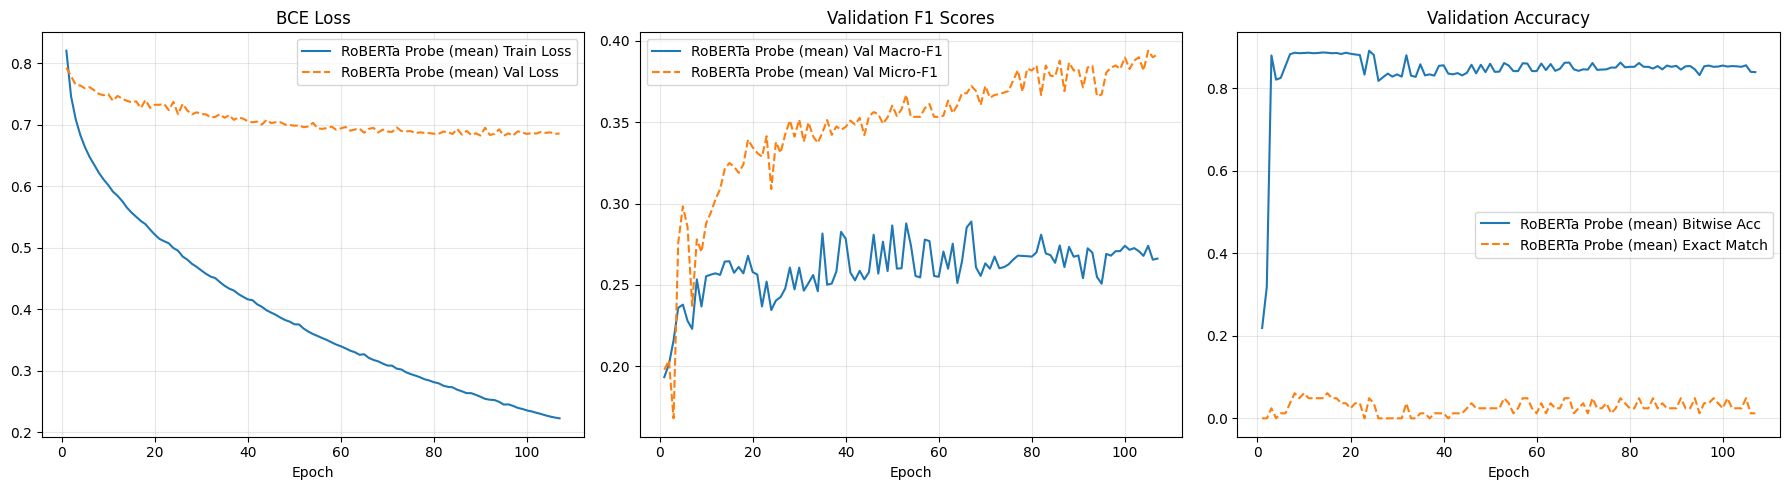


--- Final Test Evaluation ---
Test Macro-F1:  0.258
Test Micro-F1:  0.426
Test Accuracy:  0.869
Exact Match:    0.060


In [36]:
#[1]base linear probing RoBERTa

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)
MAX_LENGTH = 128

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Split
# ------------------------------------------------------------------------------
# Filter out classes with 0 positives and ensure clean lists
observed_labels = {l for ls in df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]

keep_set = set(CLASSES)
clean_labels = [[l for l in ls if l in keep_set] for ls in df["labels"]]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = [t for t, k in zip(df["text"].astype(str), has_label) if k]
Y = Y[has_label]

idx = np.arange(len(texts))

#MultilabelStratifiedShuffleSplit
tr, tmp = next(MSSS(n_splits=1, test_size=0.30, random_state=SEED).split(idx, Y))
v, t = next(MSSS(n_splits=1, test_size=0.50, random_state=SEED).split(tmp, Y[tmp]))
va, te = tmp[v], tmp[t]

X_tr_text, y_train = [texts[i] for i in tr], Y[tr]
X_va_text, y_val = [texts[i] for i in va], Y[va]
X_te_text, y_test = [texts[i] for i in te], Y[te]

# ------------------------------------------------------------------------------
# 2. Feature Extraction & Normalization
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=MAX_LENGTH, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features...")
train_feats = extract_features(X_tr_text)
val_feats = extract_features(X_va_text)
test_feats = extract_features(X_te_text)

# Choose pooling type ('mean' or 'cls')
POOLING = "mean"
X_tr, X_va, X_te = train_feats[POOLING], val_feats[POOLING], test_feats[POOLING]

# Standardize using TRAIN statistics only
mu, sd = X_tr.mean(axis=0, keepdims=True), X_tr.std(axis=0, keepdims=True) + 1e-6
X_tr_norm = (X_tr - mu) / sd
X_va_norm = (X_va - mu) / sd
X_te_norm = (X_te - mu) / sd

# ------------------------------------------------------------------------------
# 3. Dataset & Model Definition
# ------------------------------------------------------------------------------

train_ds = FeatureDataset(X_tr_norm, y_train)
val_ds = FeatureDataset(X_va_norm, y_val)
test_ds = FeatureDataset(X_te_norm, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Tamed pos_weights calculation
pos_counts = y_train.sum(axis=0)
pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)

#BCEWithLogitsLoss is used for multi label classification - to handle multiple independant tags at the same time
#pos_weight only applies to +'ve weights of a particular class and balances the ratio of the single binary decision:
#for example - ground truth =1 -> loss is x's pos_weight, else =0 -> weight not applied, hence focuses on the things
#that are in label setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)


# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
THRESHOLDS = np.arange(0.05, 0.96, 0.05)


# ------------------------------------------------------------------------------
# 5. Execution
# ------------------------------------------------------------------------------
probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

history, best_info = run_experiment(
    probe_model, optimizer, criterion, train_loader, val_loader,
    epochs=300, patience=40, name=f"RoBERTa Probe ({POOLING})"
)


all_results[f"RoBERTa Probe ({POOLING})"] = {
    "history": history,
    "best_info": best_info
}

plot_experiments(all_results)

# Final Test Evaluation with best threshold selected on validation data
test_res = evaluate_model(probe_model, test_loader, criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [37]:
#check the size of the number of tokens for the combined dataset "combined_df"
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Tokenize all texts without truncating or padding
tokenized_data = tokenizer(combined_df["text"].astype(str).tolist(), add_special_tokens=True)

# Count the tokens in each sequence
token_lengths = [len(seq) for seq in tokenized_data["input_ids"]]

# Find the absolute maximum
max_tokens = max(token_lengths)
print(f"The longest text has {max_tokens} tokens.")

# Optional: View the distribution to see if the max is just an outlier
lengths_series = pd.Series(token_lengths)
print("\nToken Length Distribution:")
print(lengths_series.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

The longest text has 216 tokens.

Token Length Distribution:
count    5262.000000
mean       34.171988
std        20.380804
min         4.000000
50%        30.000000
75%        44.000000
90%        59.000000
95%        72.000000
99%       103.390000
max       216.000000
dtype: float64


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4917.53it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting features...
  [RoBERTa Probe combined (mean)] Epoch   1/300 — Train Loss: 0.7719 | Val Loss: 0.7336 | Val Macro-F1: 0.243 | Val Acc: 0.867 | Best Thr: 0.65
  [RoBERTa Probe combined (mean)] Epoch  20/300 — Train Loss: 0.3044 | Val Loss: 0.4564 | Val Macro-F1: 0.272 | Val Acc: 0.913 | Best Thr: 0.55
  [RoBERTa Probe combined (mean)] Epoch  40/300 — Train Loss: 0.2058 | Val Loss: 0.4650 | Val Macro-F1: 0.264 | Val Acc: 0.910 | Best Thr: 0.50
[RoBERTa Probe combined (mean)] Early stopping at epoch 51


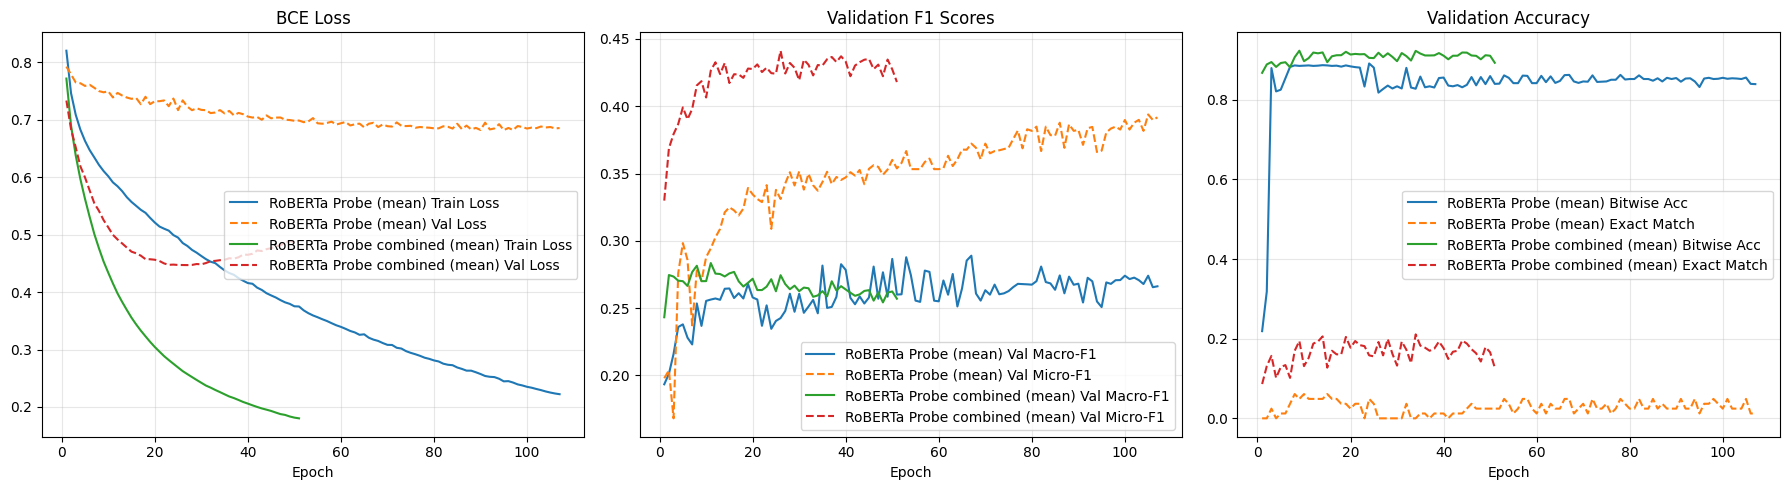


--- Final Test Evaluation ---
Test Macro-F1:  0.277
Test Micro-F1:  0.426
Test Accuracy:  0.919
Exact Match:    0.180


In [38]:
#[2]base linear probing RoBERTa combined data set

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Split
# ------------------------------------------------------------------------------
# Filter out classes with 0 positives and ensure clean lists
observed_labels = {l for ls in combined_df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]

keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in combined_df["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = combined_df.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

#MultilabelStratifiedShuffleSplit
tr, tmp = next(MSSS(n_splits=1, test_size=0.30, random_state=SEED).split(idx, Y))
v, t = next(MSSS(n_splits=1, test_size=0.50, random_state=SEED).split(tmp, Y[tmp]))
va, te = tmp[v], tmp[t]

X_tr_text, y_train = [texts[i] for i in tr], Y[tr]
X_va_text, y_val = [texts[i] for i in va], Y[va]
X_te_text, y_test = [texts[i] for i in te], Y[te]

# ------------------------------------------------------------------------------
# 2. Feature Extraction & Normalization
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=MAX_LENGTH, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features...")
train_feats = extract_features(X_tr_text)
val_feats = extract_features(X_va_text)
test_feats = extract_features(X_te_text)

# Choose pooling type ('mean' or 'cls')
POOLING = "mean"
X_tr, X_va, X_te = train_feats[POOLING], val_feats[POOLING], test_feats[POOLING]

# Standardize using TRAIN statistics only
mu, sd = X_tr.mean(axis=0, keepdims=True), X_tr.std(axis=0, keepdims=True) + 1e-6
X_tr_norm = (X_tr - mu) / sd
X_va_norm = (X_va - mu) / sd
X_te_norm = (X_te - mu) / sd

# ------------------------------------------------------------------------------
# 3. Dataset & Model Definition
# ------------------------------------------------------------------------------

train_ds = FeatureDataset(X_tr_norm, y_train)
val_ds = FeatureDataset(X_va_norm, y_val)
test_ds = FeatureDataset(X_te_norm, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Tamed pos_weights calculation
pos_counts = y_train.sum(axis=0)
pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)

#BCEWithLogitsLoss is used for multi label classification - to handle multiple independant tags at the same time
#pos_weight only applies to +'ve weights of a particular class and balances the ratio of the single binary decision:
#for example - ground truth =1 -> loss is x's pos_weight, else =0 -> weight not applied, hence focuses on the things
#that are in label setup
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)


# ------------------------------------------------------------------------------
# 4. Metric Utilities & Training Functions
# ------------------------------------------------------------------------------
THRESHOLDS = np.arange(0.05, 0.96, 0.05)


# ------------------------------------------------------------------------------
# 5. Execution
# ------------------------------------------------------------------------------
probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

history, best_info = run_experiment(
    probe_model, optimizer, criterion, train_loader, val_loader,
    epochs=300, patience=40, name=f"RoBERTa Probe combined ({POOLING})"
)

all_results[f"RoBERTa Probe combined ({POOLING})"] = {
    "history": history,
    "best_info": best_info
}
plot_experiments(all_results)

# Final Test Evaluation with best threshold selected on validation data
test_res = evaluate_model(probe_model, test_loader, criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5088.76it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting features for the entire dataset...

========== FOLD 1/5 ==========
  [Fold_1] Epoch   1/300 — Train Loss: 0.7750 | Val Loss: 0.7194 | Val Macro-F1: 0.247 | Val Acc: 0.905 | Best Thr: 0.70
  [Fold_1] Epoch  20/300 — Train Loss: 0.3102 | Val Loss: 0.4353 | Val Macro-F1: 0.310 | Val Acc: 0.907 | Best Thr: 0.50
  [Fold_1] Epoch  40/300 — Train Loss: 0.2090 | Val Loss: 0.4345 | Val Macro-F1: 0.293 | Val Acc: 0.904 | Best Thr: 0.45
[Fold_1] Early stopping at epoch 49

========== FOLD 2/5 ==========
  [Fold_2] Epoch   1/300 — Train Loss: 0.7742 | Val Loss: 0.7169 | Val Macro-F1: 0.267 | Val Acc: 0.883 | Best Thr: 0.65
  [Fold_2] Epoch  20/300 — Train Loss: 0.3084 | Val Loss: 0.4345 | Val Macro-F1: 0.308 | Val Acc: 0.916 | Best Thr: 0.55
  [Fold_2] Epoch  40/300 — Train Loss: 0.2080 | Val Loss: 0.4357 | Val Macro-F1: 0.299 | Val Acc: 0.918 | Best Thr: 0.55
[Fold_2] Early stopping at epoch 56

========== FOLD 3/5 ==========
  [Fold_3] Epoch   1/300 — Train Loss: 0.7770 | Val Loss: 0.

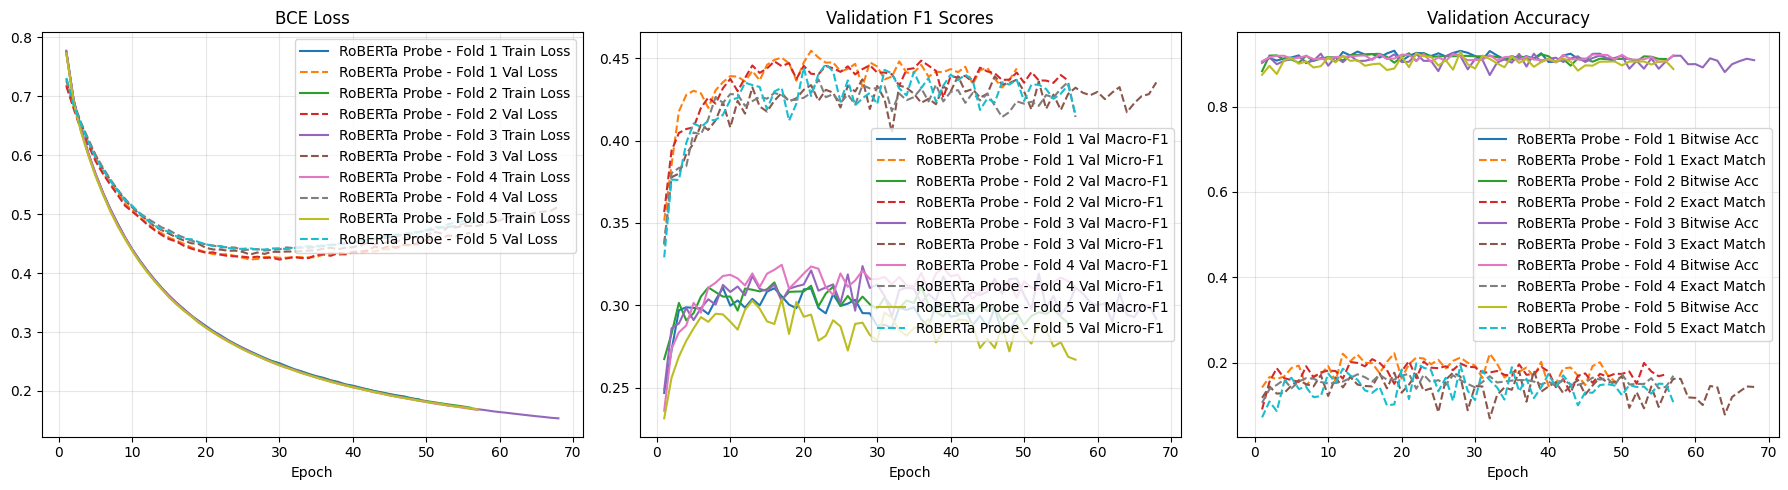


--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.315
Average Val Micro-F1: 0.436

Evaluating on Final Hold-out Test Set using model from RoBERTa Probe - Fold 4...

--- Final Test Evaluation ---
Test Macro-F1:  0.269
Test Micro-F1:  0.425
Test Accuracy:  0.900
Exact Match:    0.155


In [39]:
#apply kfold validation

# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in combined_df["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in combined_df["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = combined_df.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=128, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. K-Fold Data Splitting Setup
# ------------------------------------------------------------------------------
# A. Hold out a 15% Final Test Set first
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

X_tv, y_tv = X_all[idx_tv], Y[idx_tv]
X_test, y_test = X_all[idx_test], Y[idx_test]

# B. Setup 5-Fold Cross Validation on the remaining 85% Train/Val data
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(mskf.split(X_tv, y_tv)):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    X_tr, y_train = X_tv[train_idx], y_tv[train_idx]
    X_va, y_val = X_tv[val_idx], y_tv[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=300, patience=40, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

best_model = fold_models[best_fold_idx]
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [40]:
###########################

In [41]:
!pip install Levenshtein
!pip install sentencepiece
!pip install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [Levenshtein]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 46.0 MB/s  0:00:00


In [42]:
#process used in Ng et al. (2019) subsequently used in (Ghadery et al., 2021) - 
#"LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features"


# 1. Translation helper using Facebook WMT19 models
def translate(text, model_name, sample=False):
    # Use Auto classes as WMT19 uses FSMT architecture, not Marian
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    
    # Introduce sampling to create variation rather than exact literal matches
    if sample:
        outputs = model.generate(
            **inputs, 
            do_sample=True, 
            temperature=0.8, 
            top_p=0.9,
            max_new_tokens=50
        )
    else:
        outputs = model.generate(**inputs, max_new_tokens=50)
        
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run back-translation using the models referenced in the paper
original = "If Trump isn't Hitler, Then I'm a Moron"

# English to German (Standard generation)
german = translate(original, "facebook/wmt19-en-de")

# German back to English (Enable sampling here to force varied phrasing)
back_translated = translate(german, "facebook/wmt19-de-en", sample=True)

print(f"German: {german}")
print(f"Back-translated: {back_translated}\n")

# 2. Validation Metrics
edit_distance = Levenshtein.distance(original, back_translated)

bleu_score = nltk.translate.bleu_score.sentence_bleu(
    [original.lower().split()], 
    back_translated.lower().split(),
    weights=(0.5, 0.5, 0, 0)
)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([original, back_translated])
semantic_similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

print(f"Original: {original}")
print(f"Paraphrase: {back_translated}")
print(f"Edit Distance: {edit_distance}")
print(f"BLEU Overlap: {bleu_score:.4f}")
print(f"Semantic Similarity: {semantic_similarity:.4f}")

Loading weights: 100%|██████████| 255/255 [00:00<00:00, 4724.09it/s]
[transformers] Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Loading weights: 100%|██████████| 255/255 [00:00<00:00, 4930.74it/s]
[transformers] Both `max_new_tokens` (=50) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


German: Wenn Trump nicht Hitler ist, dann bin ich ein Idiot
Back-translated: If Trump isn't Hitler, then I'm an idiot

Original: If Trump isn't Hitler, Then I'm a Moron
Paraphrase: If Trump isn't Hitler, then I'm an idiot
Edit Distance: 6
BLEU Overlap: 0.7319
Semantic Similarity: 0.6328


In [46]:

def get_wordnet_pos(tag):
    """Maps NLTK POS tags to WordNet POS tags."""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return None

def substitute_synonyms(text, replacement_prob=0.20):
    """
    Replaces words in a sentence with random WordNet synonyms based on POS tags.
    replacement_prob controls the probability (e.g., 20%) that an eligible word gets swapped.
    """
    words = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(words)
    
    new_words = []
    for word, tag in pos_tags:
        wn_pos = get_wordnet_pos(tag)
        # Skip short words, punctuation, or non-matching POS tags
        if wn_pos and len(word) > 2 and random.random() < replacement_prob:
            synsets = wordnet.synsets(word, pos=wn_pos)
            lemmas = [l.name().replace('_', ' ') for s in synsets for l in s.lemmas() if l.name().lower() != word.lower()]
            if lemmas:
                new_words.append(random.choice(lemmas))
                continue
        new_words.append(word)
        
    return " ".join(new_words)

def translate_batch(texts, model_name, sample=False):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
    
    if sample:
        outputs = model.generate(
            **inputs, 
            do_sample=True, 
            temperature=0.8, 
            top_p=0.9, 
            max_new_tokens=64
        )
    else:
        outputs = model.generate(**inputs, max_new_tokens=64)
        
    return tokenizer.batch_decode(outputs, skip_special_tokens=True)

# Process in batches
batch_size = 16
augmented_rows = []

for i in range(0, len(df), batch_size):
    batch_df = df.iloc[i:i+batch_size]
    original_texts = batch_df['text'].tolist()
    
    # Batch back-translation
    german_texts = translate_batch(original_texts, "facebook/wmt19-en-de", sample=False)
    paraphrased_texts = translate_batch(german_texts, "facebook/wmt19-de-en", sample=True)
    
    # Apply synonym replacement across the paraphrased batch
    final_texts = [substitute_synonyms(text, replacement_prob=0.20) for text in paraphrased_texts]
    
    # Reconstruct augmented rows preserving original labels
    for (_, row), final_text in zip(batch_df.iterrows(), final_texts):
        augmented_rows.append({
            'id': f"{row['id']}_aug_de",
            'labels': row['labels'],
            'text': final_text,
            'text_key': f"{row['text_key']}_aug_de" if pd.notna(row['text_key']) else f"{row['id']}_aug_de"
        })

# Combine original and augmented
# df_combined = pd.concat([df, pd.DataFrame(augmented_rows)], ignore_index=True)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/ec2-user/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/ec2-user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
Loading weights: 100%|██████████| 255/255 [00:00<00:00, 4963.03it/s]
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Loading weights: 100%|██████████| 255/255 [00:00<00:00, 5109.19it/s]
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Loading weig

In [47]:


def verify_augmentation(df_original, augmented_data):
    """
    Compares original and augmented texts row-by-row to verify differences.
    
    Parameters:
    - df_original: pandas.DataFrame (the original input dataframe)
    - augmented_data: list or pandas.DataFrame (the generated augmented rows)
    
    Returns:
    - comparison_df: pandas.DataFrame with side-by-side comparison and metrics
    """
    # Convert augmented_data list to DataFrame if necessary
    if isinstance(augmented_data, list):
        df_aug = pd.DataFrame(augmented_data)
    else:
        df_aug = augmented_data.copy()
        
    # Build side-by-side comparison DataFrame
    comparison_df = pd.DataFrame({
        'original_id': df_original['id'].values,
        'augmented_id': df_aug['id'].values,
        'original_text': df_original['text'].values,
        'augmented_text': df_aug['text'].values,
    })
    
    # Check for exact string matches (ignoring leading/trailing whitespace)
    comparison_df['is_exact_match'] = (
        comparison_df['original_text'].str.strip() == comparison_df['augmented_text'].str.strip()
    )
    
    # Measure character-level edit distance
    comparison_df['edit_distance'] = [
        Levenshtein.distance(orig, aug) 
        for orig, aug in zip(comparison_df['original_text'], comparison_df['augmented_text'])
    ]
    
    # Calculate summary metrics
    total_samples = len(comparison_df)
    exact_matches = comparison_df['is_exact_match'].sum()
    unique_paraphrases = total_samples - exact_matches
    uniqueness_rate = (unique_paraphrases / total_samples) * 100 if total_samples > 0 else 0
    avg_edit_dist = comparison_df['edit_distance'].mean()
    
    # Print summary report
    print("=== Augmentation Verification Report ===")
    print(f"Total samples evaluated:     {total_samples}")
    print(f"Successfully paraphrased:    {unique_paraphrases} ({uniqueness_rate:.2f}%)")
    print(f"Identical texts remaining:   {exact_matches} ({100 - uniqueness_rate:.2f}%)")
    print(f"Average edit distance:       {avg_edit_dist:.2f} characters\n")
    
    if exact_matches > 0:
        print(f"⚠️  Notice: {exact_matches} text(s) did not change during back-translation.")
    else:
        print("✅ Success: All augmented texts are distinct from the original entries!")
        
    return comparison_df

# --- Usage Example (Run directly after Option 2) ---
comparison_results = verify_augmentation(df, augmented_rows)

# View all identical entries (if any exist):
duplicates = comparison_results[comparison_results['is_exact_match']]
print(duplicates[['original_id', 'original_text', 'augmented_text']])

=== Augmentation Verification Report ===
Total samples evaluated:     545
Successfully paraphrased:    541 (99.27%)
Identical texts remaining:   4 (0.73%)
Average edit distance:       50.29 characters

⚠️  Notice: 4 text(s) did not change during back-translation.
     original_id                         original_text  \
268  420_batch_2              DANCE My Bitches Dance\n   
283  443_batch_2                  The Brain Dead Bunch   
477           78          ISIS Employee of the Month\n   
524           93  The Real Virus Threatening America\n   

                         augmented_text  
268              DANCE My Bitches Dance  
283                The Brain Dead Bunch  
477          ISIS Employee of the Month  
524  The Real Virus Threatening America  


In [49]:
#drop the four that are the same
df_aug = pd.DataFrame(augmented_rows)
df_aug_filtered = df_aug[~comparison_results['is_exact_match']].copy()



In [50]:
display(df_aug_filtered.head())

,id,labels,text,text_key
0,1_aug_de,"[Causal Oversimplification, Glittering general...",8 long time OF OBAMA4 MILLION YEARS OF EMPLOYM...,8 YEARS UNDER OBAMA 4 MILLION JOBS LOST UNEMPL...
1,100_batch_2_aug_de,"[Smears, Thought-terminating cliché]",If Amy cony Barrett does n't have the common s...,If Amy Coney Barrett doesn't have the common s...
2,102_aug_de,"[Doubt, Exaggeration/Minimisation, Name callin...",I HAVE A hazard TO BE THE FIRST Gay- UNITED ST...,I HAVE A CHANCE TO BE THE FIRST GAY UNITED STA...
3,103_batch_2_aug_de,[Smears],BURGER KING `` Forget the presidentship for a ...,"BURGER KING ""Forget about the Presidency for a..."
4,104_aug_de,"[Appeal to fear/prejudice, Loaded Language, Sl...",SCARE TATICS BY THE LAST .Closed companiesClos...,SCARE TATICS BY THE LEFT. Close businesses Clo...


In [52]:
#combine unique augmented to 
df_augmented_combined = pd.concat([df, df_aug_filtered], ignore_index=True)

print(f"Original dataset size: {len(df)}")
print(f"Filtered augmented samples added: {len(df_aug_filtered)}")
print(f"Final combined dataset size: {len(df_augmented_combined)}")

Original dataset size: 545
Filtered augmented samples added: 541
Final combined dataset size: 1086


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4957.51it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting features for the entire dataset...

========== FOLD 1/5 ==========
  [Fold_1] Epoch   1/300 — Train Loss: 0.8080 | Val Loss: 0.7715 | Val Macro-F1: 0.211 | Val Acc: 0.864 | Best Thr: 0.70
  [Fold_1] Epoch  20/300 — Train Loss: 0.4637 | Val Loss: 0.6051 | Val Macro-F1: 0.575 | Val Acc: 0.921 | Best Thr: 0.80
  [Fold_1] Epoch  40/300 — Train Loss: 0.3310 | Val Loss: 0.4974 | Val Macro-F1: 0.630 | Val Acc: 0.929 | Best Thr: 0.75
  [Fold_1] Epoch  60/300 — Train Loss: 0.2464 | Val Loss: 0.4515 | Val Macro-F1: 0.643 | Val Acc: 0.932 | Best Thr: 0.75
  [Fold_1] Epoch  80/300 — Train Loss: 0.1859 | Val Loss: 0.4208 | Val Macro-F1: 0.648 | Val Acc: 0.932 | Best Thr: 0.70
  [Fold_1] Epoch 100/300 — Train Loss: 0.1441 | Val Loss: 0.4083 | Val Macro-F1: 0.640 | Val Acc: 0.936 | Best Thr: 0.80
  [Fold_1] Epoch 120/300 — Train Loss: 0.1134 | Val Loss: 0.4002 | Val Macro-F1: 0.657 | Val Acc: 0.936 | Best Thr: 0.75
  [Fold_1] Epoch 140/300 — Train Loss: 0.0902 | Val Loss: 0.4014 | Val Macr

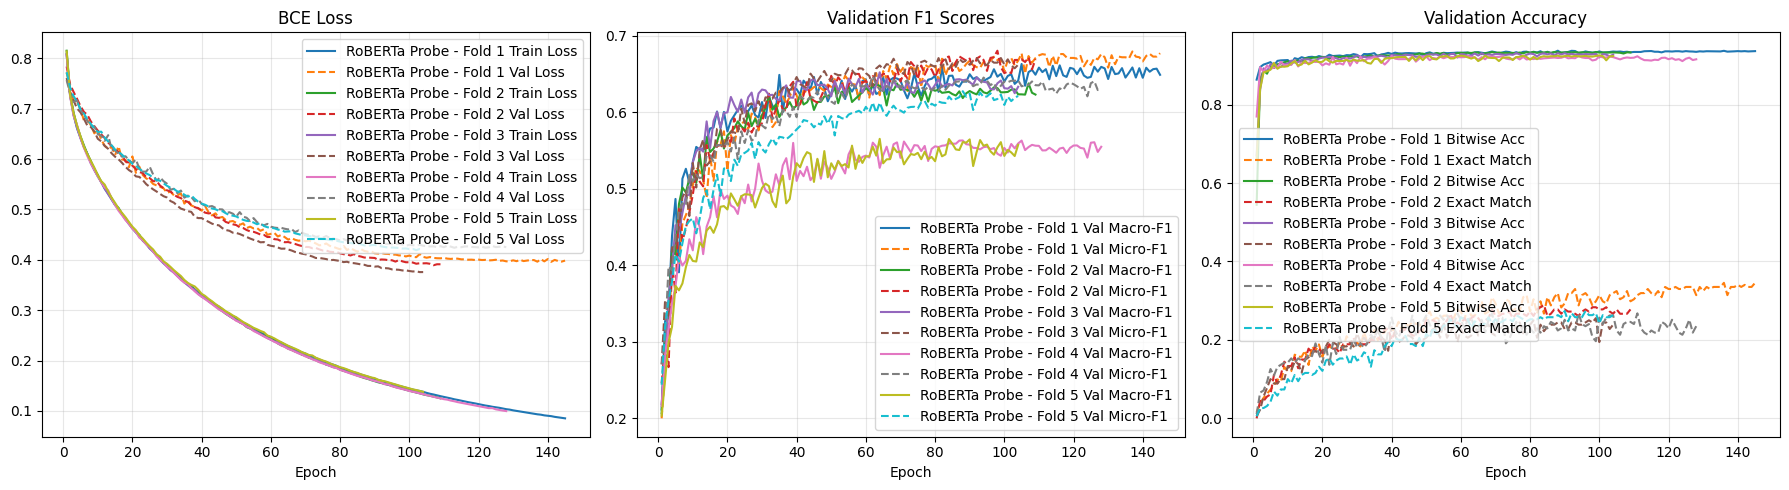


--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.616
Average Val Micro-F1: 0.649

Evaluating on Final Hold-out Test Set using model from RoBERTa Probe - Fold 1...

--- Final Test Evaluation ---
Test Macro-F1:  0.601
Test Micro-F1:  0.663
Test Accuracy:  0.928
Exact Match:    0.247


In [53]:
#apply kfold validation with the df_augmented_combined dataset kfold stratification

# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in df_augmented_combined["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in df_augmented_combined["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = df_augmented_combined.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=128, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. K-Fold Data Splitting Setup
# ------------------------------------------------------------------------------
# A. Hold out a 15% Final Test Set first
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

X_tv, y_tv = X_all[idx_tv], Y[idx_tv]
X_test, y_test = X_all[idx_test], Y[idx_test]

# B. Setup 5-Fold Cross Validation on the remaining 85% Train/Val data
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(mskf.split(X_tv, y_tv)):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    X_tr, y_train = X_tv[train_idx], y_tv[train_idx]
    X_va, y_val = X_tv[val_idx], y_tv[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=300, patience=40, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

best_model = fold_models[best_fold_idx]
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

Final combined - df,ptc-aug dataset size: 5803


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4836.45it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting features for the entire dataset...

========== FOLD 1/5 ==========
  [Fold_1] Epoch   1/300 — Train Loss: 0.7710 | Val Loss: 0.7208 | Val Macro-F1: 0.256 | Val Acc: 0.910 | Best Thr: 0.70
  [Fold_1] Epoch  20/300 — Train Loss: 0.3007 | Val Loss: 0.4206 | Val Macro-F1: 0.355 | Val Acc: 0.888 | Best Thr: 0.45
  [Fold_1] Epoch  40/300 — Train Loss: 0.2066 | Val Loss: 0.4235 | Val Macro-F1: 0.371 | Val Acc: 0.913 | Best Thr: 0.50
  [Fold_1] Epoch  60/300 — Train Loss: 0.1689 | Val Loss: 0.4537 | Val Macro-F1: 0.354 | Val Acc: 0.876 | Best Thr: 0.30
[Fold_1] Early stopping at epoch 74

========== FOLD 2/5 ==========
  [Fold_2] Epoch   1/300 — Train Loss: 0.7678 | Val Loss: 0.7256 | Val Macro-F1: 0.249 | Val Acc: 0.863 | Best Thr: 0.65
  [Fold_2] Epoch  20/300 — Train Loss: 0.2979 | Val Loss: 0.4269 | Val Macro-F1: 0.370 | Val Acc: 0.926 | Best Thr: 0.60
  [Fold_2] Epoch  40/300 — Train Loss: 0.2038 | Val Loss: 0.4335 | Val Macro-F1: 0.359 | Val Acc: 0.919 | Best Thr: 0.55
  [Fold

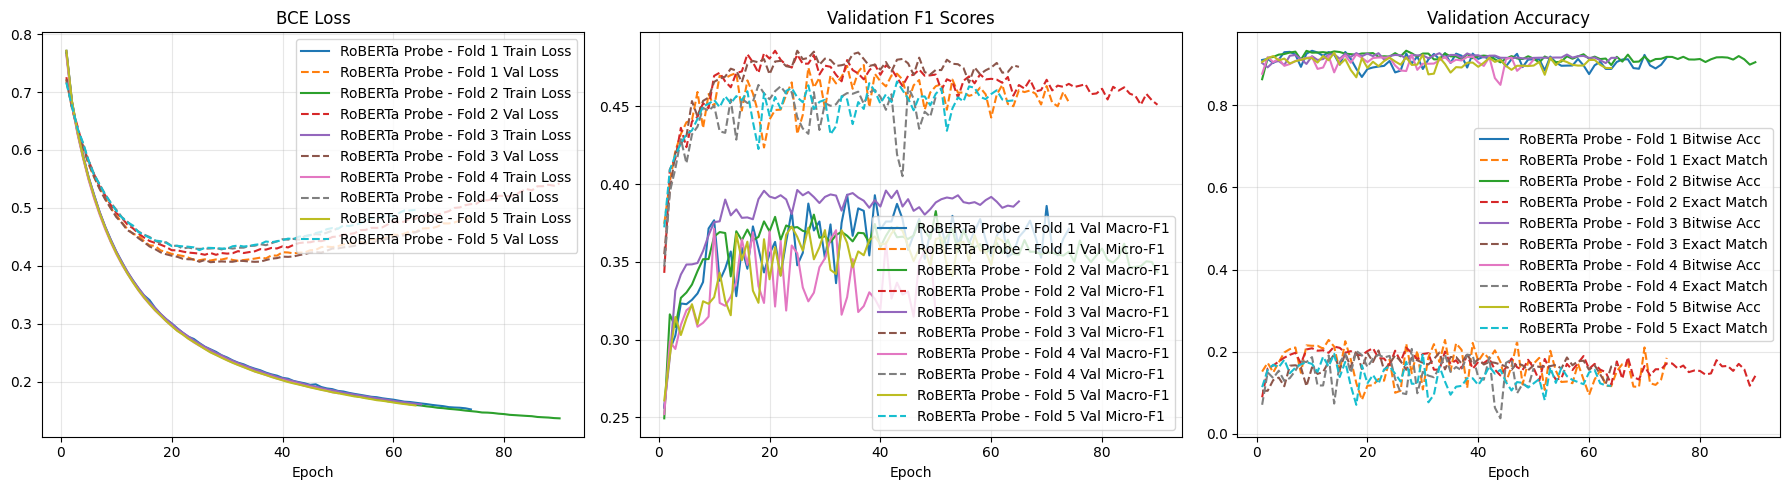


--- Cross Validation Summary (5 Folds) ---
Average Val Macro-F1: 0.383
Average Val Micro-F1: 0.469

Evaluating on Final Hold-out Test Set using model from RoBERTa Probe - Fold 3...

--- Final Test Evaluation ---
Test Macro-F1:  0.366
Test Micro-F1:  0.463
Test Accuracy:  0.907
Exact Match:    0.170


In [55]:
#add the augmented data to the combined_df which is the PTC sentance data set and the df
#apply kfold validation with the df_augmented_combined dataset kfold stratification

#combine unique augmented to 
df_ptc_augmented_combined = pd.concat([combined_df, df_aug_filtered], ignore_index=True)
print(f"Final combined - df,ptc-aug dataset size: {len(df_ptc_augmented_combined)}")


# Make sure you have imported the iterative stratification modules
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold, MultilabelStratifiedShuffleSplit

# Set seed & device
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. Label Processing & Multilabel Setup
# ------------------------------------------------------------------------------
observed_labels = {l for ls in df_ptc_augmented_combined["labels"] for l in ls}
CLASSES = [c for c in sorted(df_labels) if c in observed_labels]
keep_set = set(CLASSES)
clean_labels = [
    [l for l in ls if l in keep_set]
    for ls in df_ptc_augmented_combined["labels"]
]

mlb = MultiLabelBinarizer(classes=CLASSES)
Y = mlb.fit_transform(clean_labels).astype(np.float32)

# Keep rows with at least one target class
has_label = Y.sum(axis=1) > 0
texts = df_ptc_augmented_combined.loc[has_label, "text"].astype(str).tolist()
Y = Y[has_label]

idx = np.arange(len(texts))

# ------------------------------------------------------------------------------
# 2. Feature Extraction (Optimized: Done once for ALL text)
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

@torch.no_grad()
def extract_features(text_list, max_length=128, batch_size=32):
    out = {"mean": [], "cls": []}
    for i in range(0, len(text_list), batch_size):
        b = tokenizer(text_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        h = encoder(**b).last_hidden_state
        m = b["attention_mask"].unsqueeze(-1).to(h.dtype)

        out["mean"].append(((h * m).sum(dim=1) / m.sum(dim=1)).cpu())
        out["cls"].append(h[:, 0].cpu())

    return {k: torch.cat(v).numpy() for k, v in out.items()}

print("Extracting features for the entire dataset...")
all_feats = extract_features(texts)

POOLING = "mean"
X_all = all_feats[POOLING]

# ------------------------------------------------------------------------------
# 3. K-Fold Data Splitting Setup
# ------------------------------------------------------------------------------
# A. Hold out a 15% Final Test Set first
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

X_tv, y_tv = X_all[idx_tv], Y[idx_tv]
X_test, y_test = X_all[idx_test], Y[idx_test]

# B. Setup 5-Fold Cross Validation on the remaining 85% Train/Val data
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []

all_results = {} # Assuming this holds results for plot_experiments

for fold, (train_idx, val_idx) in enumerate(mskf.split(X_tv, y_tv)):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    X_tr, y_train = X_tv[train_idx], y_tv[train_idx]
    X_va, y_val = X_tv[val_idx], y_tv[val_idx]

    # Standardize using current fold's TRAIN statistics
    mu = X_tr.mean(axis=0, keepdims=True)
    sd = X_tr.std(axis=0, keepdims=True) + 1e-6
    X_tr_norm = (X_tr - mu) / sd
    X_va_norm = (X_va - mu) / sd

    train_ds = FeatureDataset(X_tr_norm, y_train)
    val_ds = FeatureDataset(X_va_norm, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    probe_model = LinearProbe(in_features=X_tr_norm.shape[1], num_classes=len(CLASSES)).to(device)
    optimizer = optim.Adam(probe_model.parameters(), lr=1e-3)

    history, best_info = run_experiment(
        probe_model, optimizer, criterion, train_loader, val_loader,
        epochs=300, patience=40, name=f"Fold_{fold+1}"
    )

    # Store results for this fold
    fold_name = f"RoBERTa Probe - Fold {fold+1}"
    all_results[fold_name] = {
        "history": history,
        "best_info": best_info,
    }

# Get the 0-based index of the best epoch to retrieve other metrics
    best_epoch_idx = best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": best_info["score"], # 'score' holds the best macro_f1
        "micro_f1": history["val_micro"][best_epoch_idx], # Retrieve from history
        "mu": mu,
        "sd": sd
    }

    # Keep copies of models/criterions for final test set evaluation
    fold_models.append(copy.deepcopy(probe_model))
    fold_criterions.append(criterion)

# Plot training curves for all folds
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
# Calculate average CV metrics
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process for the hold-out test
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa Probe - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

# Normalize test set strictly using the BEST fold's statistics
best_mu = fold_results[best_fold_name]["mu"]
best_sd = fold_results[best_fold_name]["sd"]
X_te_norm = (X_test - best_mu) / best_sd

test_ds = FeatureDataset(X_te_norm, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

best_model = fold_models[best_fold_idx]
best_criterion = fold_criterions[best_fold_idx]

test_res = evaluate_model(best_model, test_loader, best_criterion)
print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

# Step 2: Fine-tuning — unfreeze the backbone and continue training the Combined Data set


========== FOLD 1/5 ==========


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4752.88it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Phase 1: Linear Probing (Training Head Only)...
Phase 2: Fine-Tuning (Training Entire Model)...
Early stopping at epoch 19

========== FOLD 2/5 ==========


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4893.47it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Phase 1: Linear Probing (Training Head Only)...
Phase 2: Fine-Tuning (Training Entire Model)...

========== FOLD 3/5 ==========


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4506.59it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Phase 1: Linear Probing (Training Head Only)...
Phase 2: Fine-Tuning (Training Entire Model)...
Early stopping at epoch 10

========== FOLD 5/5 ==========


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5333.89it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Phase 1: Linear Probing (Training Head Only)...
Phase 2: Fine-Tuning (Training Entire Model)...


KeyError: 'val_accuracy'

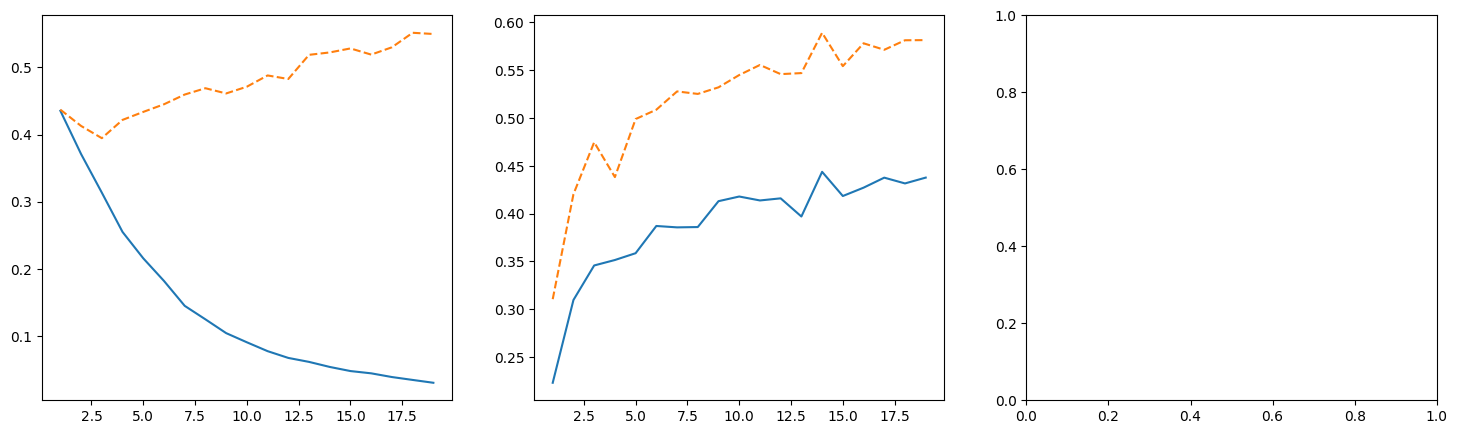

In [64]:
from transformers import AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import copy

# ------------------------------------------------------------------------------
# 2. Tokenizer Setup & Dataset Definition
# ------------------------------------------------------------------------------
MODEL_NAME = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MemeTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        # Squeeze removes the batch dimension added by return_tensors='pt'
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

# Convert texts list to numpy array for easy index-based splitting alongside Y
texts_np = np.array(texts)

# ------------------------------------------------------------------------------
# 3. K-Fold Data Splitting Setup
# ------------------------------------------------------------------------------
# A. Hold out a 15% Final Test Set first
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
idx_tv, idx_test = next(msss.split(idx, Y))

texts_tv, y_tv = texts_np[idx_tv], Y[idx_tv]
texts_test, y_test = texts_np[idx_test], Y[idx_test]

# Test set stays constant
test_ds = MemeTextDataset(texts_test, y_test, tokenizer)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# B. Setup 5-Fold Cross Validation on the remaining 85% Train/Val data
K_FOLDS = 5
mskf = MultilabelStratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# ------------------------------------------------------------------------------
# 4. K-Fold Execution Loop (Two-Phase Fine-Tuning)
# ------------------------------------------------------------------------------
fold_results = {}
fold_models = []
fold_criterions = []
all_results = {} 

for fold, (train_idx, val_idx) in enumerate(mskf.split(texts_tv, y_tv)):
    print(f"\n========== FOLD {fold + 1}/{K_FOLDS} ==========")

    texts_tr, y_train = texts_tv[train_idx], y_tv[train_idx]
    texts_va, y_val = texts_tv[val_idx], y_tv[val_idx]

    train_ds = MemeTextDataset(texts_tr, y_train, tokenizer)
    val_ds = MemeTextDataset(texts_va, y_val, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Dynamic pos_weights for current fold
    pos_counts = y_train.sum(axis=0)
    pos_weights_arr = np.sqrt((len(y_train) - pos_counts) / np.maximum(pos_counts, 1)).clip(1, 20)
    pos_weights = torch.tensor(pos_weights_arr, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    # Load a fresh, untrained model for this fold
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, 
        num_labels=len(CLASSES),
        problem_type="multi_label_classification"
    ).to(device)

    # ==========================================
    # PHASE 1: LINEAR PROBING
    # ==========================================
    # Freeze the transformer backbone (base_model covers roberta/distilbert/etc.)
    for param in model.base_model.parameters():
        param.requires_grad = False
        
    print("Phase 1: Linear Probing (Training Head Only)...")
    # Higher learning rate for the randomly initialized classifier head
    probe_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    
    probe_history, _ = run_experiment(
        model, probe_optimizer, criterion, train_loader, val_loader,
        epochs=5, name=f"Fold_{fold+1}_Probe"
    )

    # ==========================================
    # PHASE 2: FINE-TUNING
    # ==========================================
    # Unfreeze the backbone
    for param in model.base_model.parameters():
        param.requires_grad = True
        
    print("Phase 2: Fine-Tuning (Training Entire Model)...")
    # Much lower learning rate with weight decay to prevent catastrophic forgetting
    ft_optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    
    ft_history, ft_best_info = run_experiment(
        model, ft_optimizer, criterion, train_loader, val_loader,
        epochs=20, patience=5, name=f"Fold_{fold+1}_FT"
    )

    # Store Phase 2 results (this is our actual model performance)
    fold_name = f"RoBERTa FT - Fold {fold+1}"
    all_results[fold_name] = {
        "history": ft_history,
        "best_info": ft_best_info,
    }

    best_epoch_idx = ft_best_info["epoch"] - 1 

    fold_results[fold_name] = {
        "macro_f1": ft_best_info["score"], 
        "micro_f1": ft_history["val_micro"][best_epoch_idx], 
    }

    # Keep copies for final test set evaluation
    # (Be mindful of GPU memory here. If it OOMs, move models to CPU before appending: 
    # model.cpu(); fold_models.append(copy.deepcopy(model)))
    fold_models.append(copy.deepcopy(model))
    fold_criterions.append(criterion)

# Plot training curves for all folds (using Phase 2 history)
plot_experiments(all_results)

# ------------------------------------------------------------------------------
# 5. Final Evaluation
# ------------------------------------------------------------------------------
cv_macro_f1 = np.mean([res["macro_f1"] for res in fold_results.values()])
cv_micro_f1 = np.mean([res["micro_f1"] for res in fold_results.values()])

print(f"\n--- Cross Validation Summary ({K_FOLDS} Folds) ---")
print(f"Average Val Macro-F1: {cv_macro_f1:.3f}")
print(f"Average Val Micro-F1: {cv_micro_f1:.3f}")

# Select the best performing model from the CV process
best_fold_idx = np.argmax([res["macro_f1"] for res in fold_results.values()])
best_fold_name = f"RoBERTa FT - Fold {best_fold_idx+1}"
print(f"\nEvaluating on Final Hold-out Test Set using model from {best_fold_name}...")

best_model = fold_models[best_fold_idx].to(device)
best_criterion = fold_criterions[best_fold_idx]

# Ensure evaluate_model triggers your tokenizer specific logic
test_res = evaluate_model(best_model, test_loader, best_criterion)

print(f"\n--- Final Test Evaluation ---")
print(f"Test Macro-F1:  {test_res['macro_f1']:.3f}")
print(f"Test Micro-F1:  {test_res['micro_f1']:.3f}")
print(f"Test Accuracy:  {test_res['accuracy']:.3f}")
print(f"Exact Match:    {test_res['exact_match']:.3f}")

In [ ]:
#LoRA / QLoRA (PEFT):
from peft import LoraConfig, get_peft_model, TaskType




In [ ]:
# Step 2: Fine-tuning — unfreeze the backbone and continue training the SAME model

### There are 2 labels missing from your results:
    * Transfer
    * Appeal to (Strong) Emotions
    * according to the expirment these two techiques are not applicable to task 1 and task 2 (Dimitrov et al. (2021))

In [ ]:
#print off a few of the ones that had no labels
empty_labels_df.head()

word order carries meaning. Important

###Bibiography

@misc{dimitrov2021semeval2021task6detection,
      title={SemEval-2021 Task 6: Detection of Persuasion Techniques in Texts and Images},
      author={Dimitar Dimitrov and Bishr Bin Ali and Shaden Shaar and Firoj Alam and Fabrizio Silvestri and Hamed Firooz and Preslav Nakov and Giovanni Da San Martino},
      year={2021},
      eprint={2105.09284},
      archivePrefix={arXiv},
      primaryClass={cs.MM},
      url={https://arxiv.org/abs/2105.09284},
}


@misc{gupta2021voltasemeval2021task6,
      title={Volta at SemEval-2021 Task 6: Towards Detecting Persuasive Texts and Images using Textual and Multimodal Ensemble},
      author={Kshitij Gupta and Devansh Gautam and Radhika Mamidi},
      year={2021},
      eprint={2106.00240},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2106.00240},
}


@inproceedings{tian-etal-2021-mind,
    title = "{M}in{D} at {S}em{E}val-2021 Task 6: Propaganda Detection using Transfer Learning and Multimodal Fusion",
    author = "Tian, Junfeng  and
      Gui, Min  and
      Li, Chenliang  and
      Yan, Ming  and
      Xiao, Wenming",
    editor = "Palmer, Alexis  and
      Schneider, Nathan  and
      Schluter, Natalie  and
      Emerson, Guy  and
      Herbelot, Aurelie  and
      Zhu, Xiaodan",
    booktitle = "Proceedings of the 15th International Workshop on Semantic Evaluation (SemEval-2021)",
    month = aug,
    year = "2021",
    address = "Online",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2021.semeval-1.150/",
    doi = "10.18653/v1/2021.semeval-1.150",
    pages = "1082--1087",
    abstract = "We describe our systems of subtask1 and subtask3 for SemEval-2021 Task 6 on Detection of Persuasion Techniques in Texts and Images. The purpose of subtask1 is to identify propaganda techniques given textual content, and the goal of subtask3 is to detect them given both textual and visual content. For subtask1, we investigate transfer learning based on pre-trained language models (PLMs) such as BERT, RoBERTa to solve data sparsity problems. For subtask3, we extract heterogeneous visual representations (i.e., face features, OCR features, and multimodal representations) and explore various multimodal fusion strategies to combine the textual and visual representations. The official evaluation shows our ensemble model ranks 1st for subtask1 and 2nd for subtask3."
}



@InProceedings{EMNLP19DaSanMartino,
author = {Da San Martino, Giovanni and
Yu, Seunghak and
Barr\'{o}n-Cede\~no, Alberto and
Petrov, Rostislav and
Nakov, Preslav},
title = {Fine-Grained Analysis of Propaganda in News Articles},
booktitle = {Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing and 9th International Joint Conference on Natural Language Processing, EMNLP-IJCNLP 2019, Hong Kong, China, November 3-7, 2019},
series = {EMNLP-IJCNLP 2019},
year = {2019},
address = {Hong Kong, China},
month = {November},
}


@inproceedings{da-san-martino-etal-2020-semeval,
    title = "{S}em{E}val-2020 Task 11: Detection of Propaganda Techniques in News Articles",
    author = "Da San Martino, Giovanni  and
      Barr{\'o}n-Cede{\~n}o, Alberto  and
      Wachsmuth, Henning  and
      Petrov, Rostislav  and
      Nakov, Preslav",
    editor = "Herbelot, Aurelie  and
      Zhu, Xiaodan  and
      Palmer, Alexis  and
      Schneider, Nathan  and
      May, Jonathan  and
      Shutova, Ekaterina",
    booktitle = "Proceedings of the Fourteenth Workshop on Semantic Evaluation",
    month = dec,
    year = "2020",
    address = "Barcelona (online)",
    publisher = "International Committee for Computational Linguistics",
    url = "https://aclanthology.org/2020.semeval-1.186/",
    doi = "10.18653/v1/2020.semeval-1.186",
    pages = "1377--1414",
    abstract = "We present the results and the main findings of SemEval-2020 Task 11 on Detection of Propaganda Techniques in News Articles. The task featured two subtasks. Subtask SI is about Span Identification: given a plain-text document, spot the specific text fragments containing propaganda. Subtask TC is about Technique Classification: given a specific text fragment, in the context of a full document, determine the propaganda technique it uses, choosing from an inventory of 14 possible propaganda techniques. The task attracted a large number of participants: 250 teams signed up to participate and 44 made a submission on the test set. In this paper, we present the task, analyze the results, and discuss the system submissions and the methods they used. For both subtasks, the best systems used pre-trained Transformers and ensembles."
}

@inproceedings{daval-frerot-weis-2020-wmd,
    title = "{WMD} at {S}em{E}val-2020 Tasks 7 and 11: Assessing Humor and Propaganda Using Unsupervised Data Augmentation",
    author = "Daval-Frerot, Guillaume  and
      Weis, Yannick",
    editor = "Herbelot, Aurelie  and
      Zhu, Xiaodan  and
      Palmer, Alexis  and
      Schneider, Nathan  and
      May, Jonathan  and
      Shutova, Ekaterina",
    booktitle = "Proceedings of the Fourteenth Workshop on Semantic Evaluation",
    month = dec,
    year = "2020",
    address = "Barcelona (online)",
    publisher = "International Committee for Computational Linguistics",
    url = "https://aclanthology.org/2020.semeval-1.246/",
    doi = "10.18653/v1/2020.semeval-1.246",
    pages = "1865--1874",
    abstract = "In this work, we combine the state-of-the-art BERT architecture with the semi-supervised learning technique UDA in order to exploit unlabeled raw data to assess humor and detect propaganda in the tasks 7 and 11 of the SemEval-2020 competition. The use of UDA shows promising results with a systematic improvement of the performances over the four different subtasks, and even outperforms supervised learning with the additional labels of the Funlines dataset."
}

@misc{ghadery2021liirsemeval2021task6,
      title={LIIR at SemEval-2021 task 6: Detection of Persuasion Techniques In Texts and Images using CLIP features}, 
      author={Erfan Ghadery and Damien Sileo and Marie-Francine Moens},
      year={2021},
      eprint={2105.14774},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2105.14774}, 
}